<a href="https://colab.research.google.com/github/Hend-Cheikhrouhou/Machine_Learning/blob/main/weather_forcasting_part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Étape 1 : Importations & **Configuration**

In [ ]:
# Traitement des données (essentiel)
import pandas as pd
import numpy as np

# Visualisation (pour EDA)

import matplotlib.pyplot as plt

import seaborn as sns

# Prétraitement et ML (préparation future)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Configuration d'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set(style='whitegrid')

# Suppression des warnings
import warnings
warnings.filterwarnings('ignore')

# Seed pour reproductibilité
SEED = 42
np.random.seed(SEED)


# Étape 2 : Chargement & Exploration Initiale

In [ ]:
# Chargement des données
df = pd.read_csv("open_meteo_data.csv", sep=",", on_bad_lines='skip')  # ou sep=";", selon le délimiteur réel
# sep="," suppose un délimiteur par virgule. Changez en sep=";" si le délimiteur est un point-virgule.
# on_bad_lines='skip' ignore les lignes qui posent problème.

* **Exploration rapide des données**

In [ ]:
# Aperçu des premières lignes
df.head().style

,time,weather_code (wmo code),temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),wind_speed_10m_max (km/h),precipitation_sum (mm),rain_sum (mm),pressure_msl_mean (hPa),soil_moisture_0_to_7cm_mean (m³/m³),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm)
0,2000-01-01,51,8.100000,11.400000,5.000000,76,43,14.800000,1.900000,1.900000,1024.300000,0.322000,8.750000,1.350000
1,2000-01-02,51,9.400000,12.700000,6.400000,69,37,22.900000,0.300000,0.300000,1025.900000,0.327000,9.020000,1.840000
2,2000-01-03,53,9.600000,12.400000,7.400000,73,36,23.200000,2.500000,2.500000,1027.100000,0.322000,8.670000,1.630000
3,2000-01-04,3,10.600000,13.800000,8.400000,62,47,16.100000,0.000000,0.000000,1028.400000,0.318000,8.770000,1.960000
4,2000-01-05,2,9.300000,14.100000,5.100000,78,39,12.000000,0.000000,0.000000,1025.900000,0.303000,11.060000,1.520000


In [ ]:
# Taille du dataset
print("Shape:", df.shape)

Shape: (9163, 14)


In [ ]:
# Affiche la liste des noms de colonnes du DataFrame (utile pour connaître la structure des données)
df.columns

Index(['time', 'weather_code (wmo code)', 'temperature_2m_mean (°C)',
       'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'relative_humidity_2m_mean (%)', 'cloud_cover_mean (%)',
       'wind_speed_10m_max (km/h)', 'precipitation_sum (mm)', 'rain_sum (mm)',
       'pressure_msl_mean (hPa)', 'soil_moisture_0_to_7cm_mean (m³/m³)',
       'shortwave_radiation_sum (MJ/m²)', 'et0_fao_evapotranspiration (mm)'],
      dtype='object')

In [ ]:
# Types des colonnes
print(df.dtypes)

time                                    object
weather_code (wmo code)                  int64
temperature_2m_mean (°C)               float64
temperature_2m_max (°C)                float64
temperature_2m_min (°C)                float64
relative_humidity_2m_mean (%)            int64
cloud_cover_mean (%)                     int64
wind_speed_10m_max (km/h)              float64
precipitation_sum (mm)                 float64
rain_sum (mm)                          float64
pressure_msl_mean (hPa)                float64
soil_moisture_0_to_7cm_mean (m³/m³)    float64
shortwave_radiation_sum (MJ/m²)        float64
et0_fao_evapotranspiration (mm)        float64
dtype: object


In [ ]:
# Statistiques descriptives
df.describe().style

,weather_code (wmo code),temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),wind_speed_10m_max (km/h),precipitation_sum (mm),rain_sum (mm),pressure_msl_mean (hPa),soil_moisture_0_to_7cm_mean (m³/m³),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm)
count,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000
mean,16.503765,19.672989,24.383859,15.559216,66.309178,33.644330,21.348499,0.875368,0.875368,1016.404671,0.171247,18.248219,4.179088
std,23.462340,6.063309,6.818197,5.704966,10.843588,27.337597,6.552233,3.483275,3.483275,5.600452,0.074861,7.006297,1.889540
min,0.000000,5.300000,8.000000,1.700000,17.000000,0.000000,6.600000,0.000000,0.000000,991.600000,0.038000,0.780000,0.330000
25%,2.000000,14.400000,18.700000,10.700000,59.000000,9.000000,16.800000,0.000000,0.000000,1013.100000,0.110000,11.790000,2.570000
50%,3.000000,19.300000,23.900000,15.300000,67.000000,29.000000,20.300000,0.000000,0.000000,1016.000000,0.146000,18.210000,3.900000
75%,51.000000,25.100000,29.900000,20.600000,74.000000,53.000000,24.900000,0.100000,0.100000,1019.500000,0.219000,25.015000,5.740000
max,65.000000,38.900000,49.700000,30.600000,94.000000,100.000000,53.600000,103.400000,103.400000,1040.000000,0.430000,29.600000,12.430000


In [ ]:
# Valeurs manquantes
print(df.isnull().sum())

time                                   0
weather_code (wmo code)                0
temperature_2m_mean (°C)               0
temperature_2m_max (°C)                0
temperature_2m_min (°C)                0
relative_humidity_2m_mean (%)          0
cloud_cover_mean (%)                   0
wind_speed_10m_max (km/h)              0
precipitation_sum (mm)                 0
rain_sum (mm)                          0
pressure_msl_mean (hPa)                0
soil_moisture_0_to_7cm_mean (m³/m³)    0
shortwave_radiation_sum (MJ/m²)        0
et0_fao_evapotranspiration (mm)        0
dtype: int64


In [ ]:
# Vérification des doublons
df.duplicated().sum()

np.int64(0)

In [ ]:
# Conversion de date (index)
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

In [ ]:
df.head().style

,weather_code (wmo code),temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),wind_speed_10m_max (km/h),precipitation_sum (mm),rain_sum (mm),pressure_msl_mean (hPa),soil_moisture_0_to_7cm_mean (m³/m³),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm)
time,,,,,,,,,,,,,
2000-01-01 00:00:00,51,8.100000,11.400000,5.000000,76,43,14.800000,1.900000,1.900000,1024.300000,0.322000,8.750000,1.350000
2000-01-02 00:00:00,51,9.400000,12.700000,6.400000,69,37,22.900000,0.300000,0.300000,1025.900000,0.327000,9.020000,1.840000
2000-01-03 00:00:00,53,9.600000,12.400000,7.400000,73,36,23.200000,2.500000,2.500000,1027.100000,0.322000,8.670000,1.630000
2000-01-04 00:00:00,3,10.600000,13.800000,8.400000,62,47,16.100000,0.000000,0.000000,1028.400000,0.318000,8.770000,1.960000
2000-01-05 00:00:00,2,9.300000,14.100000,5.100000,78,39,12.000000,0.000000,0.000000,1025.900000,0.303000,11.060000,1.520000


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9163 entries, 2000-01-01 to 2025-01-31
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   weather_code (wmo code)              9163 non-null   int64  
 1   temperature_2m_mean (°C)             9163 non-null   float64
 2   temperature_2m_max (°C)              9163 non-null   float64
 3   temperature_2m_min (°C)              9163 non-null   float64
 4   relative_humidity_2m_mean (%)        9163 non-null   int64  
 5   cloud_cover_mean (%)                 9163 non-null   int64  
 6   wind_speed_10m_max (km/h)            9163 non-null   float64
 7   precipitation_sum (mm)               9163 non-null   float64
 8   rain_sum (mm)                        9163 non-null   float64
 9   pressure_msl_mean (hPa)              9163 non-null   float64
 10  soil_moisture_0_to_7cm_mean (m³/m³)  9163 non-null   float64
 11  shortwave_ra

In [ ]:
# Pour vérifier que l'index est bien une date
print(df.index)

DatetimeIndex(['2000-01-01', '2000-01-02', '2000-01-03', '2000-01-04',
               '2000-01-05', '2000-01-06', '2000-01-07', '2000-01-08',
               '2000-01-09', '2000-01-10',
               ...
               '2025-01-22', '2025-01-23', '2025-01-24', '2025-01-25',
               '2025-01-26', '2025-01-27', '2025-01-28', '2025-01-29',
               '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', name='time', length=9163, freq=None)


In [ ]:
# Pour afficher la période couverte par les données
print("Date minimale :", df.index.min())
print("Date maximale :", df.index.max())

Date minimale : 2000-01-01 00:00:00
Date maximale : 2025-01-31 00:00:00


In [ ]:
# Extraire année, mois et jour dans des colonnes séparées
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day

In [ ]:
print(df[['year', 'month', 'day']].head())

            year  month  day
time                        
2000-01-01  2000      1    1
2000-01-02  2000      1    2
2000-01-03  2000      1    3
2000-01-04  2000      1    4
2000-01-05  2000      1    5


* Réorganiser les colonnes




In [ ]:
df = df.reset_index()  # remet 'time' comme colonne normale

In [ ]:
# Liste des colonnes actuelles
colonnes = df.columns.tolist()

# Colonnes prioritaires
ordre = ['time', 'year', 'month', 'day']

# Ajouter les autres colonnes après
autres = [col for col in colonnes if col not in ordre]

# Nouvel ordre final
df = df[ordre + autres]


In [ ]:
df.head().style

,time,year,month,day,weather_code (wmo code),temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),wind_speed_10m_max (km/h),precipitation_sum (mm),rain_sum (mm),pressure_msl_mean (hPa),soil_moisture_0_to_7cm_mean (m³/m³),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm)
0,2000-01-01 00:00:00,2000,1,1,51,8.100000,11.400000,5.000000,76,43,14.800000,1.900000,1.900000,1024.300000,0.322000,8.750000,1.350000
1,2000-01-02 00:00:00,2000,1,2,51,9.400000,12.700000,6.400000,69,37,22.900000,0.300000,0.300000,1025.900000,0.327000,9.020000,1.840000
2,2000-01-03 00:00:00,2000,1,3,53,9.600000,12.400000,7.400000,73,36,23.200000,2.500000,2.500000,1027.100000,0.322000,8.670000,1.630000
3,2000-01-04 00:00:00,2000,1,4,3,10.600000,13.800000,8.400000,62,47,16.100000,0.000000,0.000000,1028.400000,0.318000,8.770000,1.960000
4,2000-01-05 00:00:00,2000,1,5,2,9.300000,14.100000,5.100000,78,39,12.000000,0.000000,0.000000,1025.900000,0.303000,11.060000,1.520000


* Extraire des fonctionnalités temporelles utiles


In [ ]:
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.day

# Ajouter la saison selon le mois
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

df['season'] = df['month'].apply(get_season)


In [ ]:
print(df[['time', 'year', 'month', 'day', 'season']].head())


        time  year  month  day  season
0 2000-01-01  2000      1    1  winter
1 2000-01-02  2000      1    2  winter
2 2000-01-03  2000      1    3  winter
3 2000-01-04  2000      1    4  winter
4 2000-01-05  2000      1    5  winter


In [ ]:
# Affichage sans limite de colonnes
pd.set_option('display.max_columns', None)

# Réorganisation des colonnes
colonnes = df.columns.tolist()
ordre = ['time', 'year', 'month', 'day', 'season']
autres = [col for col in colonnes if col not in ordre]
df = df[ordre + autres]

# Afficher les premières lignes
df.head().style

,time,year,month,day,season,weather_code (wmo code),temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),wind_speed_10m_max (km/h),precipitation_sum (mm),rain_sum (mm),pressure_msl_mean (hPa),soil_moisture_0_to_7cm_mean (m³/m³),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm)
0,2000-01-01 00:00:00,2000,1,1,winter,51,8.100000,11.400000,5.000000,76,43,14.800000,1.900000,1.900000,1024.300000,0.322000,8.750000,1.350000
1,2000-01-02 00:00:00,2000,1,2,winter,51,9.400000,12.700000,6.400000,69,37,22.900000,0.300000,0.300000,1025.900000,0.327000,9.020000,1.840000
2,2000-01-03 00:00:00,2000,1,3,winter,53,9.600000,12.400000,7.400000,73,36,23.200000,2.500000,2.500000,1027.100000,0.322000,8.670000,1.630000
3,2000-01-04 00:00:00,2000,1,4,winter,3,10.600000,13.800000,8.400000,62,47,16.100000,0.000000,0.000000,1028.400000,0.318000,8.770000,1.960000
4,2000-01-05 00:00:00,2000,1,5,winter,2,9.300000,14.100000,5.100000,78,39,12.000000,0.000000,0.000000,1025.900000,0.303000,11.060000,1.520000


# Étape 3 :Nettoyage des Données (Data Cleaning)

In [ ]:
# Vérifier les types de données
print("Types de données :\n", df.dtypes)

Types de données :
 time                                   datetime64[ns]
year                                            int32
month                                           int32
day                                             int32
season                                         object
weather_code (wmo code)                         int64
temperature_2m_mean (°C)                      float64
temperature_2m_max (°C)                       float64
temperature_2m_min (°C)                       float64
relative_humidity_2m_mean (%)                   int64
cloud_cover_mean (%)                            int64
wind_speed_10m_max (km/h)                     float64
precipitation_sum (mm)                        float64
rain_sum (mm)                                 float64
pressure_msl_mean (hPa)                       float64
soil_moisture_0_to_7cm_mean (m³/m³)           float64
shortwave_radiation_sum (MJ/m²)               float64
et0_fao_evapotranspiration (mm)               float64
dtype: o

In [ ]:
# convertir la colonne season en catégorie pour optimiser la mémoire (au lieu de object)
df['season'] = df['season'].astype('category')

In [ ]:
# verfication que c'est fait la transformation du type
print("Types de données :\n", df.dtypes)

Types de données :
 time                                   datetime64[ns]
year                                            int32
month                                           int32
day                                             int32
season                                       category
weather_code (wmo code)                         int64
temperature_2m_mean (°C)                      float64
temperature_2m_max (°C)                       float64
temperature_2m_min (°C)                       float64
relative_humidity_2m_mean (%)                   int64
cloud_cover_mean (%)                            int64
wind_speed_10m_max (km/h)                     float64
precipitation_sum (mm)                        float64
rain_sum (mm)                                 float64
pressure_msl_mean (hPa)                       float64
soil_moisture_0_to_7cm_mean (m³/m³)           float64
shortwave_radiation_sum (MJ/m²)               float64
et0_fao_evapotranspiration (mm)               float64
dtype: o

In [ ]:
# Vérifier les valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


Valeurs manquantes par colonne :
time                                   0
year                                   0
month                                  0
day                                    0
season                                 0
weather_code (wmo code)                0
temperature_2m_mean (°C)               0
temperature_2m_max (°C)                0
temperature_2m_min (°C)                0
relative_humidity_2m_mean (%)          0
cloud_cover_mean (%)                   0
wind_speed_10m_max (km/h)              0
precipitation_sum (mm)                 0
rain_sum (mm)                          0
pressure_msl_mean (hPa)                0
soil_moisture_0_to_7cm_mean (m³/m³)    0
shortwave_radiation_sum (MJ/m²)        0
et0_fao_evapotranspiration (mm)        0
dtype: int64


In [ ]:
# Supprimer les doublons
df = df.drop_duplicates()

In [ ]:
# Supprimer ou traiter les valeurs manquantes (ici, suppression simple)
df = df.dropna()

In [ ]:
# Identifier et supprimer les colonnes identiques
# Exemple : vérifier si deux colonnes sont identiques
import matplotlib.pyplot as plt
import seaborn as sns

# Comparer les colonnes "precipitation_sum" et "rain_sum"
col1 = 'precipitation_sum (mm)'
col2 = 'rain_sum (mm)'

# Vérifier si les deux colonnes sont identiques
are_columns_identical = df[col1].equals(df[col2])
print(f"Les colonnes '{col1}' et '{col2}' sont identiques: {are_columns_identical}")

# Comparaison élément par élément (True si les valeurs sont identiques, sinon False)
comparison = df[col1] == df[col2]

# Calculer le pourcentage de valeurs identiques
identical_percentage = (comparison.sum() / len(comparison)) * 100
print(f"Pourcentage des valeurs identiques entre '{col1}' et '{col2}': {identical_percentage:.2f}%")

# Si les colonnes sont identiques, on supprime 'precipitation_sum' du DataFrame
if are_columns_identical:
    df = df.drop(columns=[col1])
    print(f"La colonne '{col1}' a été supprimée du DataFrame.")
else:
    print(f"La colonne '{col1}' n'a pas été supprimée, car elle n'est pas identique à '{col2}'.")

Les colonnes 'precipitation_sum (mm)' et 'rain_sum (mm)' sont identiques: True
Pourcentage des valeurs identiques entre 'precipitation_sum (mm)' et 'rain_sum (mm)': 100.00%
La colonne 'precipitation_sum (mm)' a été supprimée du DataFrame.


In [ ]:
# Vérifier la nouvelle forme du DataFrame
print("\nForme finale du DataFrame :", df.shape)


Forme finale du DataFrame : (9163, 17)


In [ ]:
df.head().style


,time,year,month,day,season,weather_code (wmo code),temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),wind_speed_10m_max (km/h),rain_sum (mm),pressure_msl_mean (hPa),soil_moisture_0_to_7cm_mean (m³/m³),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm)
0,2000-01-01 00:00:00,2000,1,1,winter,51,8.100000,11.400000,5.000000,76,43,14.800000,1.900000,1024.300000,0.322000,8.750000,1.350000
1,2000-01-02 00:00:00,2000,1,2,winter,51,9.400000,12.700000,6.400000,69,37,22.900000,0.300000,1025.900000,0.327000,9.020000,1.840000
2,2000-01-03 00:00:00,2000,1,3,winter,53,9.600000,12.400000,7.400000,73,36,23.200000,2.500000,1027.100000,0.322000,8.670000,1.630000
3,2000-01-04 00:00:00,2000,1,4,winter,3,10.600000,13.800000,8.400000,62,47,16.100000,0.000000,1028.400000,0.318000,8.770000,1.960000
4,2000-01-05 00:00:00,2000,1,5,winter,2,9.300000,14.100000,5.100000,78,39,12.000000,0.000000,1025.900000,0.303000,11.060000,1.520000


In [ ]:
df.to_csv("data_cleaned.csv", index=False)


# ÉTAPE 4 : Analyse Exploratoire des Données (EDA)

* 1 - Vue générale sur les statistiques

In [ ]:
print("Résumé statistique :")
df.describe().style

Résumé statistique :


,time,year,month,day,weather_code (wmo code),temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),wind_speed_10m_max (km/h),rain_sum (mm),pressure_msl_mean (hPa),soil_moisture_0_to_7cm_mean (m³/m³),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm)
count,9163,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000,9163.000000
mean,2012-07-17 00:00:00,2012.043981,6.503874,15.731638,16.503765,19.672989,24.383859,15.559216,66.309178,33.644330,21.348499,0.875368,1016.404671,0.171247,18.248219,4.179088
min,2000-01-01 00:00:00,2000.000000,1.000000,1.000000,0.000000,5.300000,8.000000,1.700000,17.000000,0.000000,6.600000,0.000000,991.600000,0.038000,0.780000,0.330000
25%,2006-04-09 12:00:00,2006.000000,4.000000,8.000000,2.000000,14.400000,18.700000,10.700000,59.000000,9.000000,16.800000,0.000000,1013.100000,0.110000,11.790000,2.570000
50%,2012-07-17 00:00:00,2012.000000,7.000000,16.000000,3.000000,19.300000,23.900000,15.300000,67.000000,29.000000,20.300000,0.000000,1016.000000,0.146000,18.210000,3.900000
75%,2018-10-24 12:00:00,2018.000000,10.000000,23.000000,51.000000,25.100000,29.900000,20.600000,74.000000,53.000000,24.900000,0.100000,1019.500000,0.219000,25.015000,5.740000
max,2025-01-31 00:00:00,2025.000000,12.000000,31.000000,65.000000,38.900000,49.700000,30.600000,94.000000,100.000000,53.600000,103.400000,1040.000000,0.430000,29.600000,12.430000
std,nan,7.239391,3.458056,8.801537,23.462340,6.063309,6.818197,5.704966,10.843588,27.337597,6.552233,3.483275,5.600452,0.074861,7.006297,1.889540


In [ ]:
df.describe (include= "number")

,year,month,day,weather_code (wmo code),temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),wind_speed_10m_max (km/h),rain_sum (mm),pressure_msl_mean (hPa),soil_moisture_0_to_7cm_mean (m³/m³),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm)
count,9163.00,9163.00,9163.00,9163.00,9163.00,9163.00,9163.00,9163.00,9163.00,9163.00,9163.00,9163.00,9163.00,9163.00,9163.00
mean,2012.04,6.50,15.73,16.50,19.67,24.38,15.56,66.31,33.64,21.35,0.88,1016.40,0.17,18.25,4.18
std,7.24,3.46,8.80,23.46,6.06,6.82,5.70,10.84,27.34,6.55,3.48,5.60,0.07,7.01,1.89
min,2000.00,1.00,1.00,0.00,5.30,8.00,1.70,17.00,0.00,6.60,0.00,991.60,0.04,0.78,0.33
25%,2006.00,4.00,8.00,2.00,14.40,18.70,10.70,59.00,9.00,16.80,0.00,1013.10,0.11,11.79,2.57
50%,2012.00,7.00,16.00,3.00,19.30,23.90,15.30,67.00,29.00,20.30,0.00,1016.00,0.15,18.21,3.90
75%,2018.00,10.00,23.00,51.00,25.10,29.90,20.60,74.00,53.00,24.90,0.10,1019.50,0.22,25.02,5.74
max,2025.00,12.00,31.00,65.00,38.90,49.70,30.60,94.00,100.00,53.60,103.40,1040.00,0.43,29.60,12.43


In [ ]:
df.describe (include= "category")

,season
count,9163
unique,4
top,spring
freq,2300


In [ ]:
print("\nTypes de données :")
print(df.dtypes)


Types de données :
time                                   datetime64[ns]
year                                            int32
month                                           int32
day                                             int32
season                                       category
weather_code (wmo code)                         int64
temperature_2m_mean (°C)                      float64
temperature_2m_max (°C)                       float64
temperature_2m_min (°C)                       float64
relative_humidity_2m_mean (%)                   int64
cloud_cover_mean (%)                            int64
wind_speed_10m_max (km/h)                     float64
rain_sum (mm)                                 float64
pressure_msl_mean (hPa)                       float64
soil_moisture_0_to_7cm_mean (m³/m³)           float64
shortwave_radiation_sum (MJ/m²)               float64
et0_fao_evapotranspiration (mm)               float64
dtype: object


In [ ]:
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())



Valeurs manquantes par colonne :
time                                   0
year                                   0
month                                  0
day                                    0
season                                 0
weather_code (wmo code)                0
temperature_2m_mean (°C)               0
temperature_2m_max (°C)                0
temperature_2m_min (°C)                0
relative_humidity_2m_mean (%)          0
cloud_cover_mean (%)                   0
wind_speed_10m_max (km/h)              0
rain_sum (mm)                          0
pressure_msl_mean (hPa)                0
soil_moisture_0_to_7cm_mean (m³/m³)    0
shortwave_radiation_sum (MJ/m²)        0
et0_fao_evapotranspiration (mm)        0
dtype: int64


*  2 - Analyse univariée (1 variable à la fois)

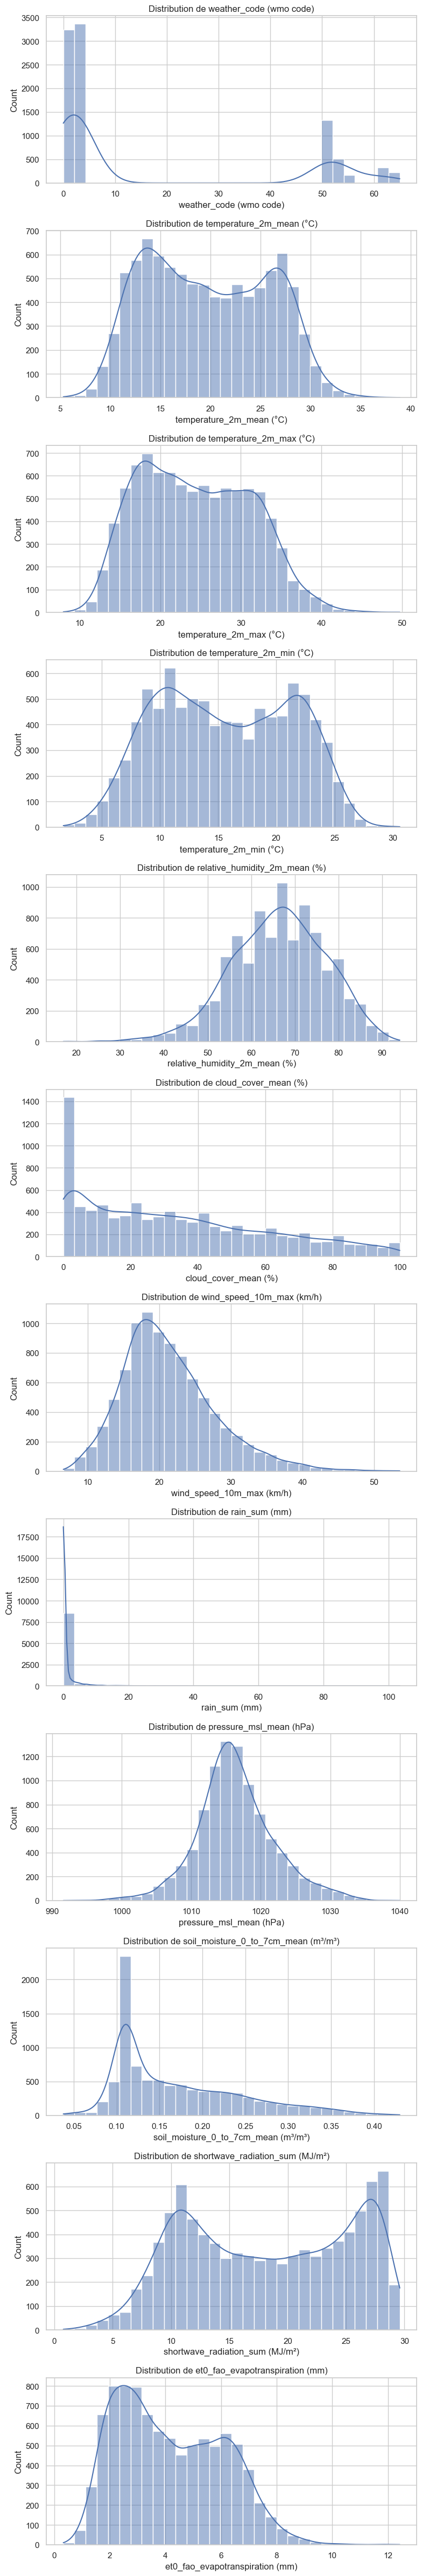

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Crée une grille de subplots verticalement
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=1, figsize=(8, 4 * len(numeric_cols)))

# S'assurer que axes est toujours un tableau
if len(numeric_cols) == 1:
    axes = [axes]

# Dessiner chaque histogramme dans un sous-plot
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=ax)
    ax.set_title(f"Distribution de {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()




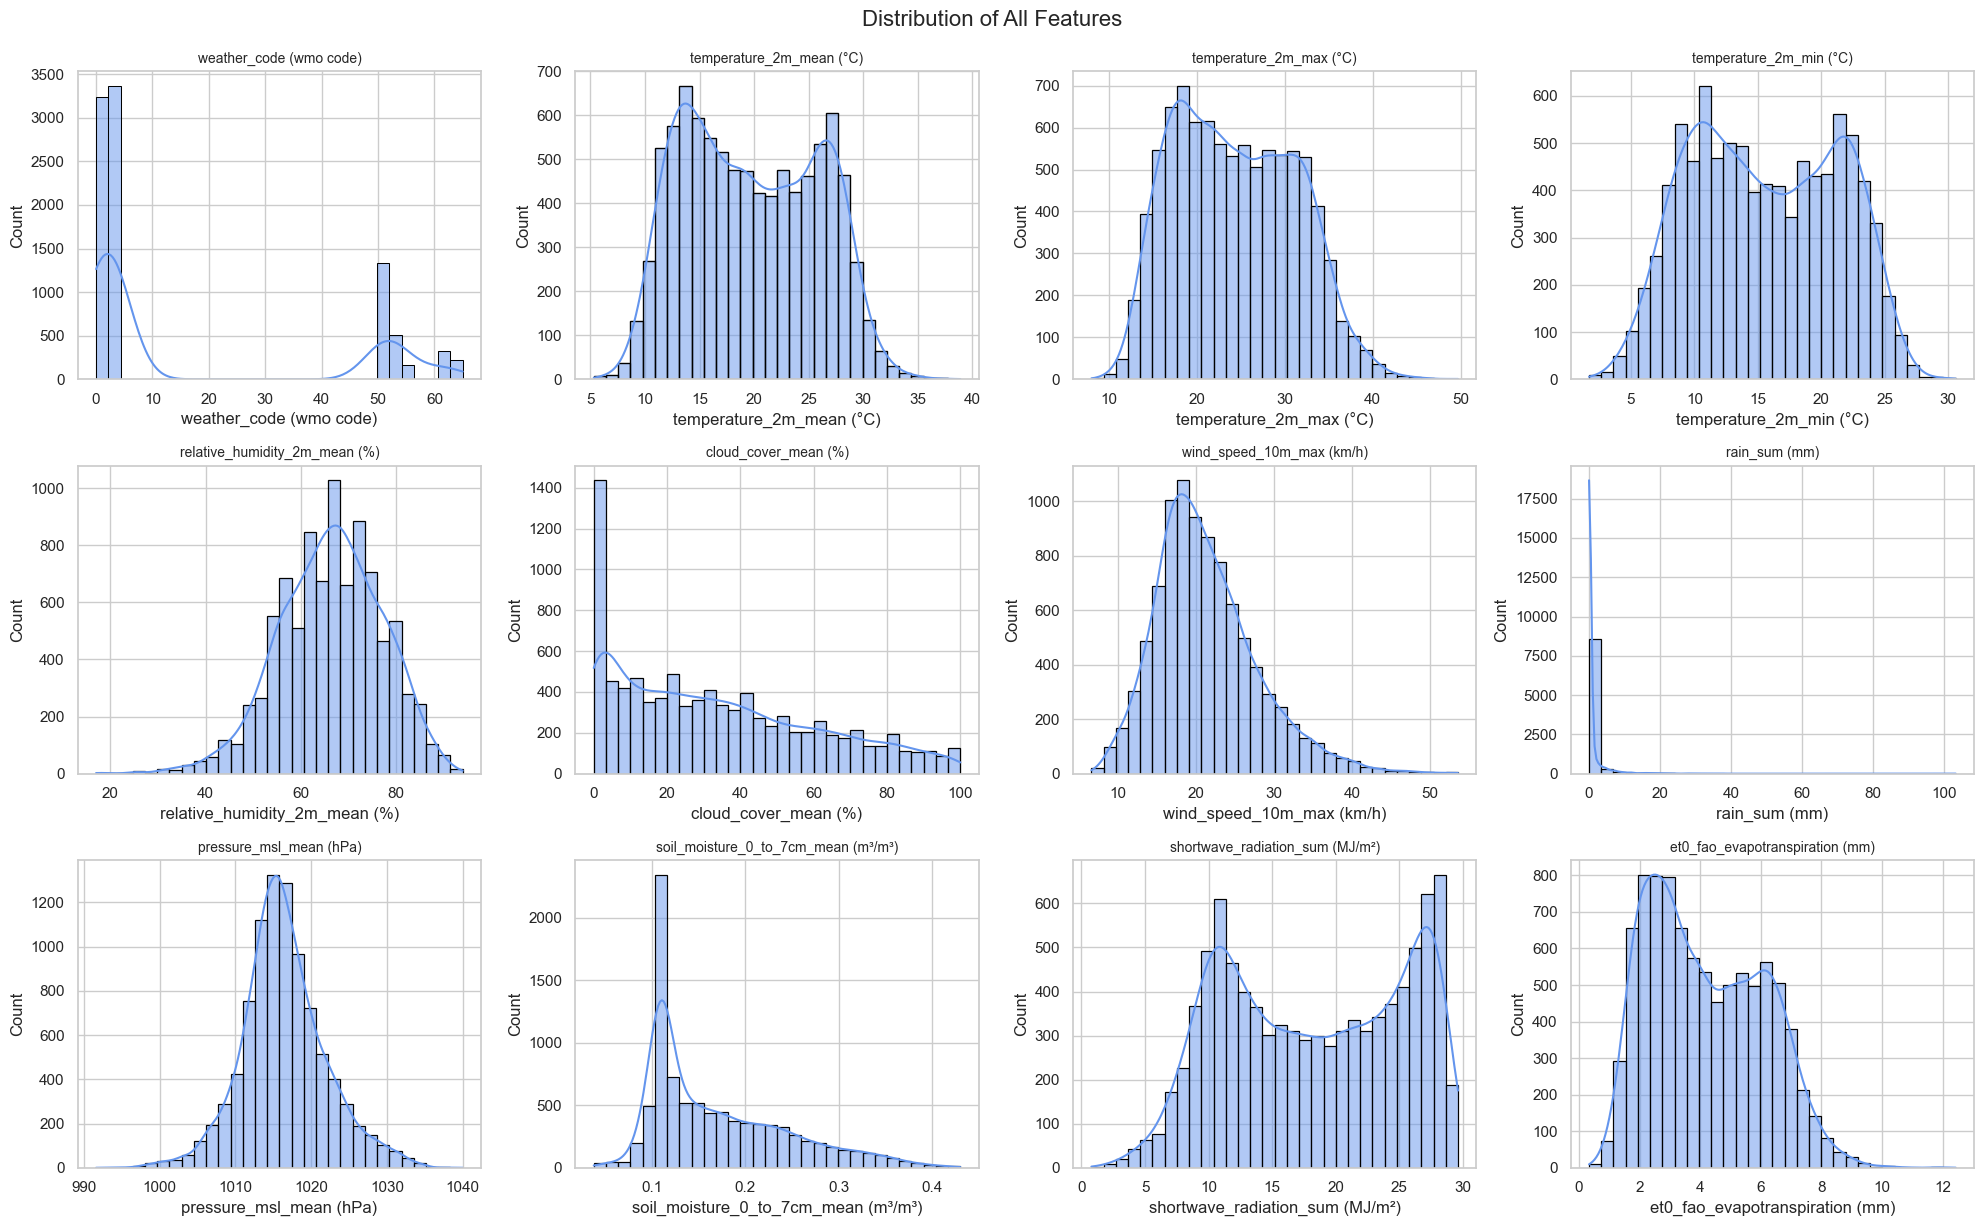

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner uniquement les colonnes numériques
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Définir la taille et la structure de la grille
n_cols = 4  # Nombre de graphes par ligne
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # Calcul du nombre de lignes

# Taille globale de la figure
plt.figure(figsize=(n_cols * 5, n_rows * 4))

# Créer chaque sous-graphe
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, bins=30, color='cornflowerblue', edgecolor='black')
    plt.title(col, fontsize=10)
    plt.tight_layout()

plt.suptitle("Distribution of All Features", fontsize=16, y=1.02)
plt.show()


### A-1 Variable Cible


In [ ]:
# Compter le nombre d’occurrences de chaque code météo
df["weather_code (wmo code)"].value_counts()


weather_code (wmo code)
3     3363
51    1329
0     1250
2     1033
1      959
53     514
61     327
63     209
55     166
65      13
Name: count, dtype: int64

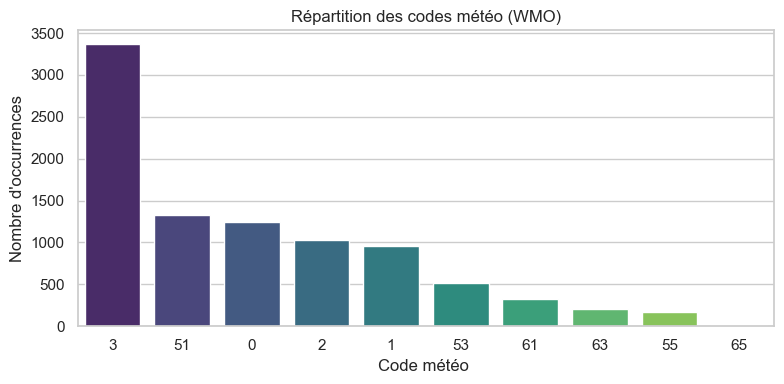

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.countplot(x="weather_code (wmo code)", data=df, order=df["weather_code (wmo code)"].value_counts().index, palette="viridis")
plt.title("Répartition des codes météo (WMO)")
plt.xlabel("Code météo ")
plt.ylabel("Nombre d'occurrences")
plt.tight_layout()
plt.show()


In [ ]:
df["weather_code (wmo code)"].value_counts()[1]


np.int64(959)

In [ ]:
second_most_common = df["weather_code (wmo code)"].value_counts().index[1]
count = df["weather_code (wmo code)"].value_counts()[1]


In [ ]:
# Identifier le code météo qui est le 2ᵉ plus fréquent
second_most_common = df["weather_code (wmo code)"].value_counts().index[1]

# Obtenir le nombre d’occurrences de ce code météo
count = df["weather_code (wmo code)"].value_counts()[1]

# Afficher le résultat avec un message explicite
print(f"Le 2ᵉ type météo le plus fréquent est le code {second_most_common} avec {count} occurrences.")



Le 2ᵉ type météo le plus fréquent est le code 51 avec 959 occurrences.


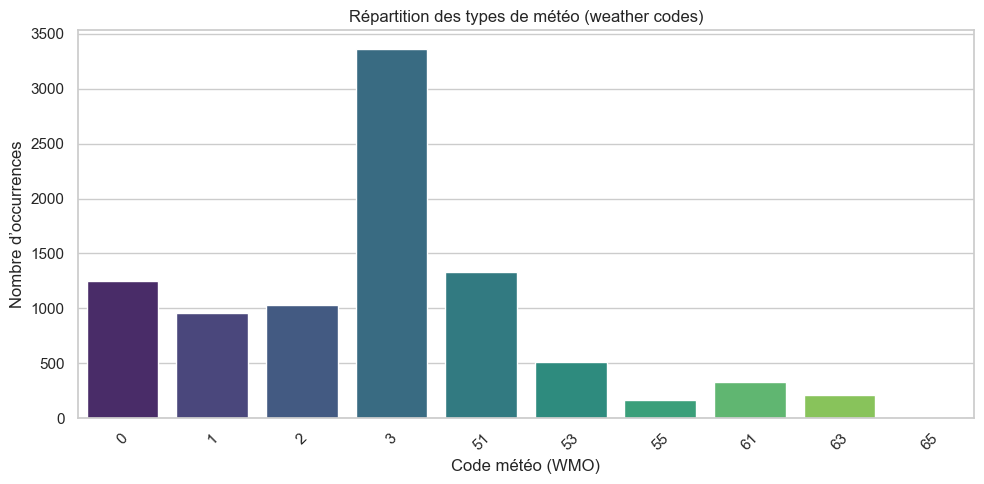

Type météo 3 : 36.70% des observations
Type météo 51 : 14.50% des observations
Type météo 0 : 13.64% des observations


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Afficher la distribution des types météo
plt.figure(figsize=(10, 5))
sns.countplot(x='weather_code (wmo code)', data=df, palette='viridis')
plt.title("Répartition des types de météo (weather codes)")
plt.xlabel("Code météo (WMO)")
plt.ylabel("Nombre d’occurrences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculer et afficher les pourcentages des codes météo
code_counts = df['weather_code (wmo code)'].value_counts(normalize=True) * 100

# Afficher les 3 codes météo les plus fréquents
for i, (code, pct) in enumerate(code_counts.items()):
    print(f"Type météo {code} : {pct:.2f}% des observations")
    if i == 2:  # Afficher uniquement les 3 premiers
        break


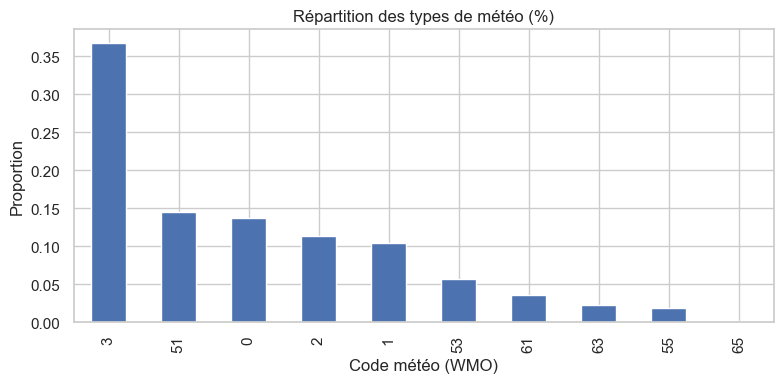

In [ ]:
# Affiche la proportion de chaque type de météo (en %) sous forme de graphique à barres
df["weather_code (wmo code)"].value_counts(normalize=True).plot.bar(
    title='Répartition des types de météo (%)',  # Titre du graphique
    figsize=(8, 4)  # Taille de la figure
)

# Étiquette de l'axe X
plt.xlabel("Code météo (WMO)")

# Étiquette de l'axe Y (proportion)
plt.ylabel("Proportion")

# Optimise l'affichage du graphique
plt.tight_layout()

# Affiche le graphique
plt.show()


constatation ▶

Code météo 3 domine très largement les observations (plus du 1/3 des données) → cela peut introduire un biais si on ne traite pas ce déséquilibre dans un modèle de prédiction.

Il y a une bonne diversité de types météo, mais certains sont rares (codes 55, 65, etc.), ce qui pourrait poser problème pour entraîner un modèle à les prédire efficacement.

Ce déséquilibre fait que ton jeu de données est "imbalanced" → une étape de traitement ou de pondération sera probablement nécessaire.

--> le code météo 3 (météo partiellement nuageuse) représente à lui seul environ 37 % des observations. On peut dire qui'il existe un risque de mal prédire les cas rares (peu fréquentes) comme la pluie forte etc ...             Dans ce cas, on pourra envisager des stratégies comme **le rééchantillonage** (oversampling des classes minoritaires / undersampling des classes majoritaires), **le regroupement de classes** (rassemblement certains codes rares sous une classe plus génèrales (pluie légère,modérée neige, etc ..)),**poids de classe dans les modéles** (intégrer des poids de classes dons les modéles (comme : class-weight = 'Balanced' pour SVM , logistic regression, etc..)), **Evaluation des métriques adaptées** (utiliser la f-mesure, matrice de confusion, etc..)

### A-2 Variables indépendantes catégorielles

In [ ]:
# Affiche le nombre d'occurrences pour chaque saison dans le DataFrame
# Cette information est utile pour comprendre le contexte météorologique dominant dans ton dataset
df["season"].value_counts()


season
spring    2300
summer    2300
winter    2288
autumn    2275
Name: count, dtype: int64

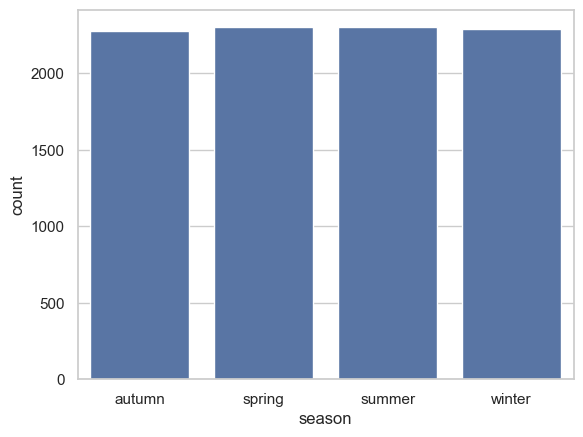

In [ ]:
sns.countplot(x='season', data = df);

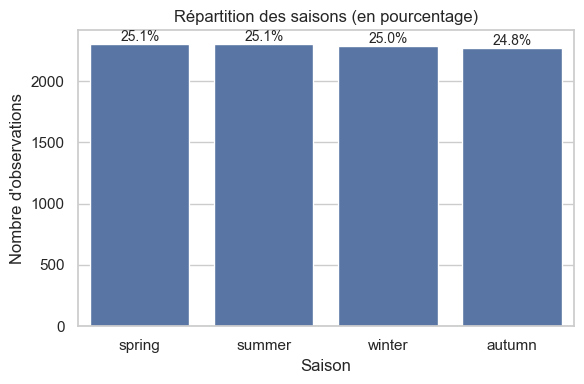

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculer les proportions manuellement
season_counts = df['season'].value_counts(normalize=True)  # normalize=True pour obtenir les proportions
season_order = season_counts.index  # pour garder l'ordre naturel

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='season', data=df, order=season_order)

# Ajouter les pourcentages au-dessus des barres
for p in ax.patches:
    height = p.get_height()
    total = len(df)
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

plt.title('Répartition des saisons (en pourcentage)')
plt.xlabel('Saison')
plt.ylabel('Nombre d\'observations')
plt.tight_layout()
plt.show()


--> commentaire : La répartition des observations selon les saisons est très équilibrée :

Spring (printemps) : 2 300 soit 25.1%

Summer (été) : 2 300 soit 25.1%

Winter (hiver) : 2 288 soit 25.0%

Autumn (automne) : 2 275 soit 24.8%                                                    

Cela signifie qu’il n’y a pas de biais saisonnier majeur dans les données.
Chaque saison est représentée de manière quasi équivalente, ce qui est idéal pour analyser l’impact de la saisonnalité sur la météo ou d'autres variables.

**Conclusion : Pas besoin de correction ou de rééchantillonnage sur cette variable.

### A-3 Variables numériques


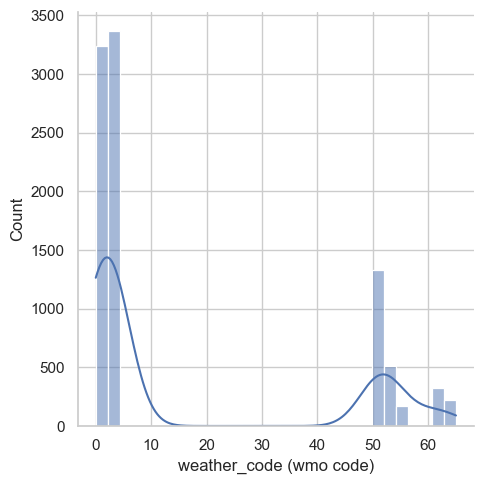

In [ ]:
# Affiche la distribution de la variable cible "weather_code (wmo code)"
# Cela permet de visualiser la fréquence de chaque type de météo dans le dataset
# C'est utile pour détecter un éventuel déséquilibre entre les différentes classes météo
sns.displot(df["weather_code (wmo code)"], kde=True, bins=30);

<Axes: ylabel='weather_code (wmo code)'>

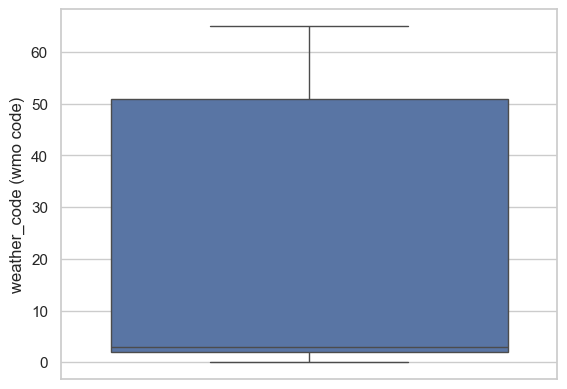

In [ ]:
# Affiche un boxplot (boîte à moustaches) de la variable cible "weather_code (wmo code)"
# Ce type de graphique permet de détecter des valeurs aberrantes (outliers) éventuelles
# et de visualiser la dispersion/statistiques de la variable cible
sns.boxplot(df["weather_code (wmo code)"])

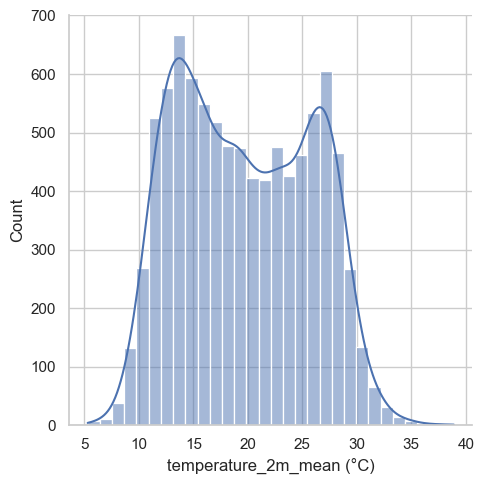

In [ ]:
# Affiche une distribution continue (histogramme + courbe de densité) de la température moyenne
sns.displot(df["temperature_2m_mean (°C)"], kde=True, bins=30);


<Axes: ylabel='temperature_2m_mean (°C)'>

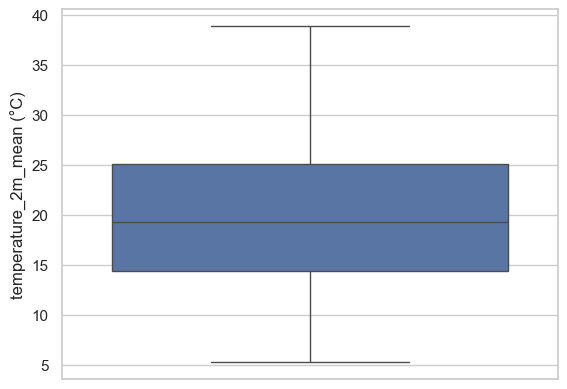

In [ ]:
# Affiche un boxplot (boîte à moustaches) pour la variable "temperature_2m_mean (°C)"
# Cela aide à détecter rapidement les éventuelles valeurs aberrantes dans la température moyenne.
sns.boxplot(df["temperature_2m_mean (°C)"])

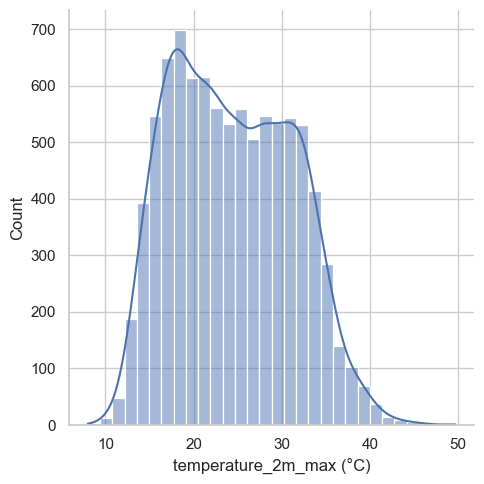

In [ ]:
# Affiche l'histogramme de la variable "temperature_2m_max (°C)" avec une courbe de densité (kde)
# - L'histogramme montre la distribution des valeurs de température maximale.
# - La courbe de densité (kde=True) permet de visualiser la tendance globale de la distribution.
# - bins=30 définit le nombre d'intervalles de classes (barres de l'histogramme).
sns.displot(df["temperature_2m_max (°C)"], kde=True, bins=30)


<Axes: ylabel='temperature_2m_max (°C)'>

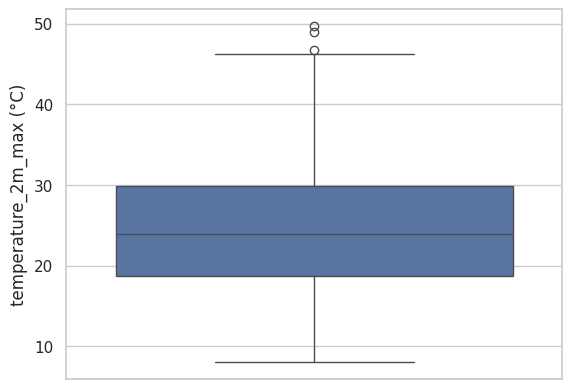

In [ ]:
# Affiche un boxplot (boîte à moustaches) pour la variable "temperature_2m_max (°C)"
# - Permet de visualiser la distribution statistique des températures maximales.
# - Met en évidence la médiane, les quartiles (Q1, Q3) et les valeurs extrêmes (outliers).
# - Utile pour détecter les anomalies ou les données aberrantes (températures très élevées ou très basses).
sns.boxplot(df["temperature_2m_max (°C)"])

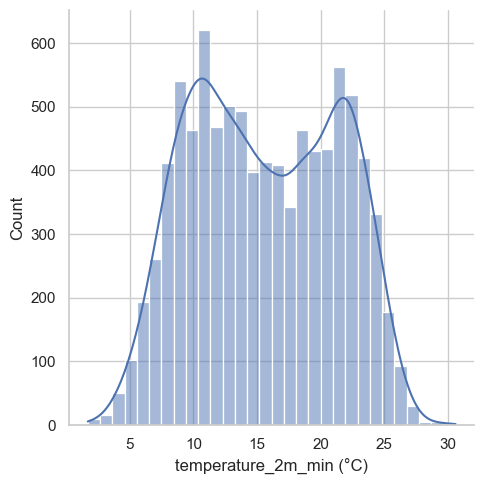

In [ ]:
# Affiche l'histogramme de la variable "temperature_2m_min (°C)" avec une courbe KDE (estimation de densité)
# - Permet de visualiser la distribution des températures minimales.
# - Le paramètre `bins=30` divise les données en 30 intervalles pour plus de précision.
# - `kde=True` ajoute une courbe lissée représentant la densité de probabilité.
# - Utile pour repérer la tendance centrale, la dispersion et la forme de la distribution (symétrique, biaisée, etc.).
sns.displot(df["temperature_2m_min (°C)"], kde=True, bins=30)


<Axes: ylabel='temperature_2m_min (°C)'>

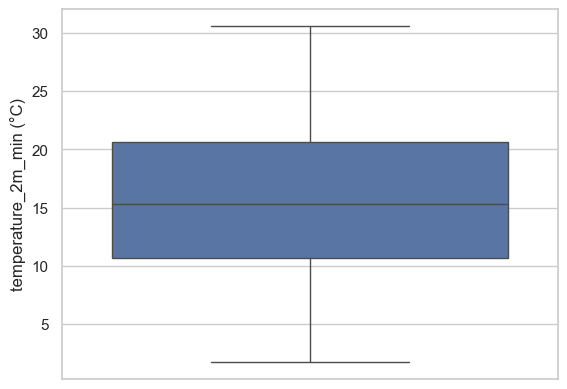

In [ ]:
# Affiche un boxplot (boîte à moustaches) de la température minimale (°C)
# Utile pour voir la médiane, la dispersion et les valeurs extrêmes (outliers)
sns.boxplot(df["temperature_2m_min (°C)"])


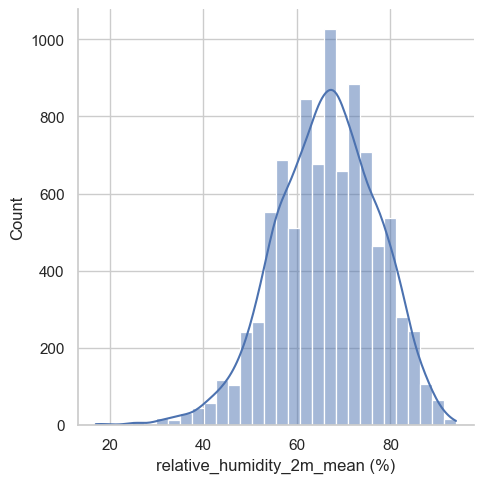

In [ ]:
# Affiche la distribution de l'humidité relative moyenne (%)
# Permet de visualiser la forme de la répartition et détecter d’éventuelles asymétries
sns.displot(df["relative_humidity_2m_mean (%)"], kde=True, bins=30)


<Axes: ylabel='relative_humidity_2m_mean (%)'>

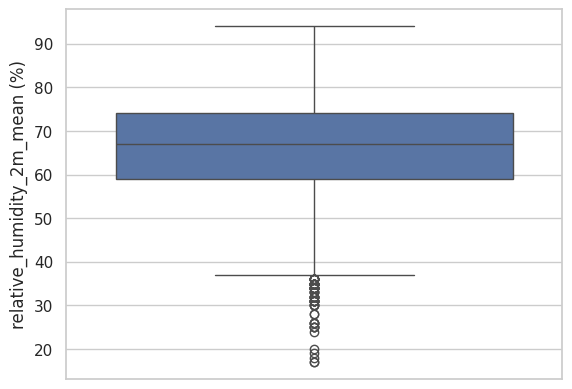

In [ ]:
# Affiche un boxplot (boîte à moustaches) de la relative_humidity_2m_mean (%)
# Utile pour voir la médiane, la dispersion et les valeurs extrêmes (outliers)
sns.boxplot(df["relative_humidity_2m_mean (%)"])

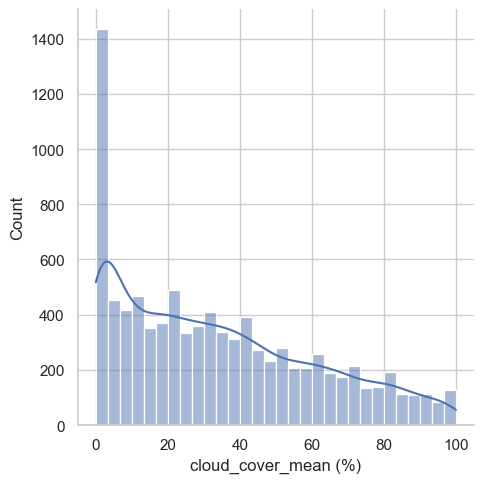

In [ ]:
# Affiche la distribution de cloud_cover_mean (%)
# Permet de visualiser la forme de la répartition et détecter d’éventuelles asymétries
sns.displot(df["cloud_cover_mean (%)"], kde=True, bins=30)

<Axes: ylabel='cloud_cover_mean (%)'>

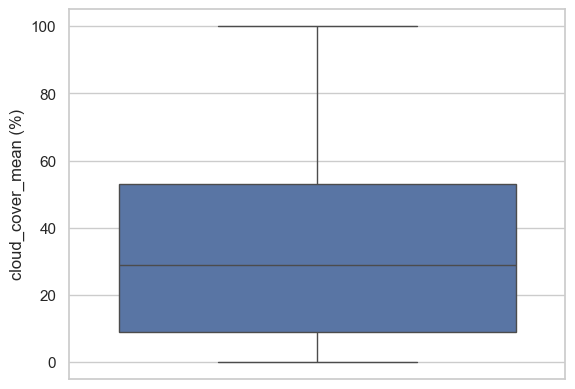

In [ ]:
# Affiche un boxplot (boîte à moustaches) de cloud_cover_mean (%)
# Utile pour voir la médiane, la dispersion et les valeurs extrêmes (outliers)
sns.boxplot(df["cloud_cover_mean (%)"])

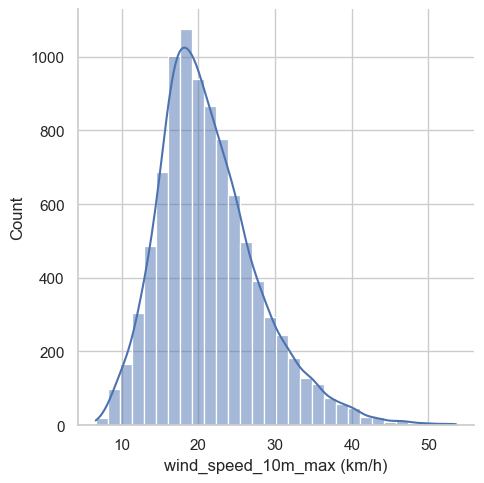

In [ ]:
# Affiche la distribution de wind_speed_10m_max (km/h)
# Permet de visualiser la forme de la répartition et détecter d’éventuelles asymétries
sns.displot(df["wind_speed_10m_max (km/h)"], kde=True, bins=30)

<Axes: ylabel='wind_speed_10m_max (km/h)'>

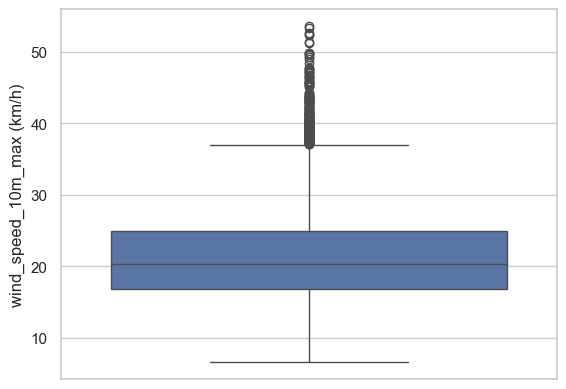

In [ ]:
# Affiche un boxplot (boîte à moustaches) de wind_speed_10m_max (km/h)
# Utile pour voir la médiane, la dispersion et les valeurs extrêmes (outliers)
sns.boxplot(df["wind_speed_10m_max (km/h)"])

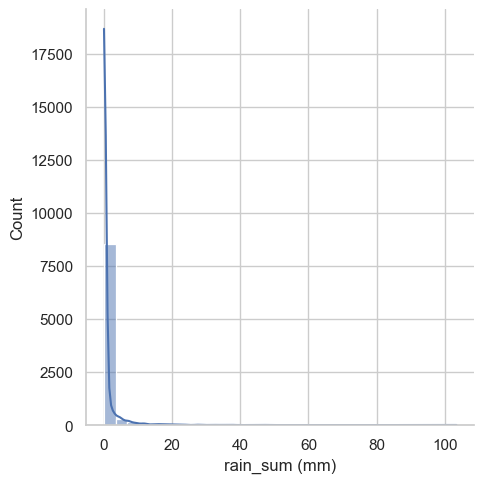

In [ ]:
# Affiche la distribution de rain_sum (mm)
# Permet de visualiser la forme de la répartition et détecter d’éventuelles asymétries
sns.displot(df["rain_sum (mm)"], kde=True, bins=30)

<Axes: ylabel='rain_sum (mm)'>

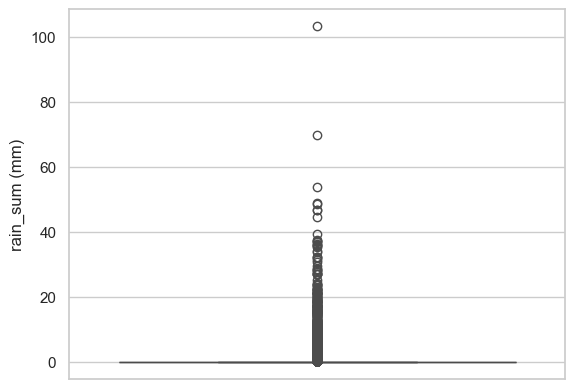

In [ ]:
# Affiche un boxplot (boîte à moustaches) de rain_sum (mm)
# Utile pour voir la médiane, la dispersion et les valeurs extrêmes (outliers)
sns.boxplot(df["rain_sum (mm)"])

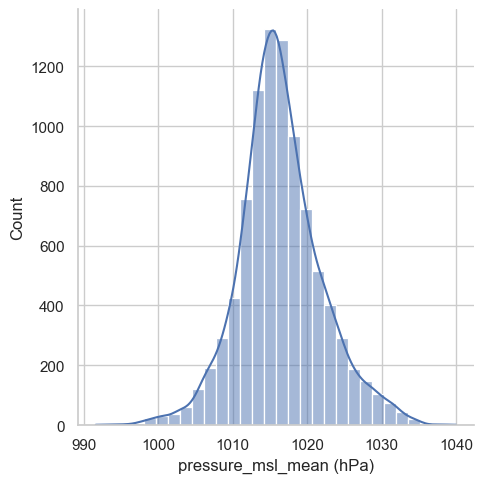

In [ ]:
# Affiche la distribution de pressure_msl_mean (hPa)
# Permet de visualiser la forme de la répartition et détecter d’éventuelles asymétries
sns.displot(df["pressure_msl_mean (hPa)"], kde=True, bins=30)

<Axes: ylabel='pressure_msl_mean (hPa)'>

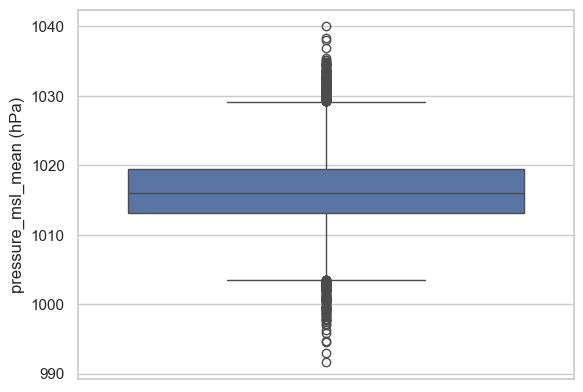

In [ ]:
# Affiche un boxplot (boîte à moustaches) de pressure_msl_mean (hPa)
# Utile pour voir la médiane, la dispersion et les valeurs extrêmes (outliers)
sns.boxplot(df["pressure_msl_mean (hPa)"])

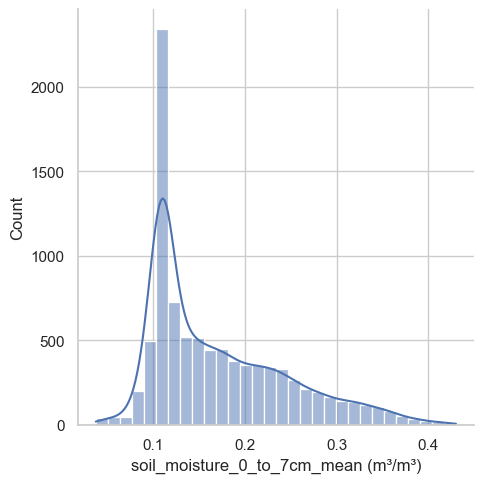

In [ ]:
# Affiche la distribution de soil_moisture_0_to_7cm_mean (m³/m³)
# Permet de visualiser la forme de la répartition et détecter d’éventuelles asymétries
sns.displot(df["soil_moisture_0_to_7cm_mean (m³/m³)"], kde=True, bins=30)

<Axes: ylabel='soil_moisture_0_to_7cm_mean (m³/m³)'>

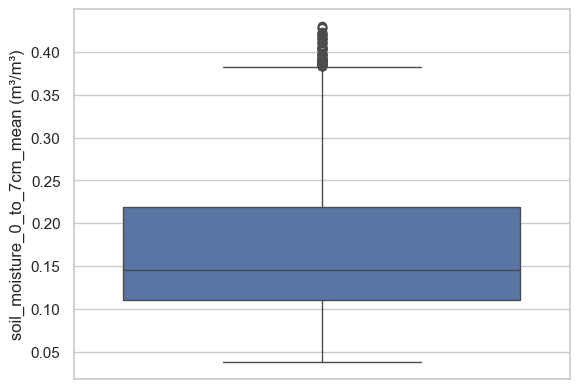

In [ ]:
# Affiche un boxplot (boîte à moustaches) de soil_moisture_0_to_7cm_mean (m³/m³)
# Utile pour voir la médiane, la dispersion et les valeurs extrêmes (outliers)
sns.boxplot(df["soil_moisture_0_to_7cm_mean (m³/m³)"])

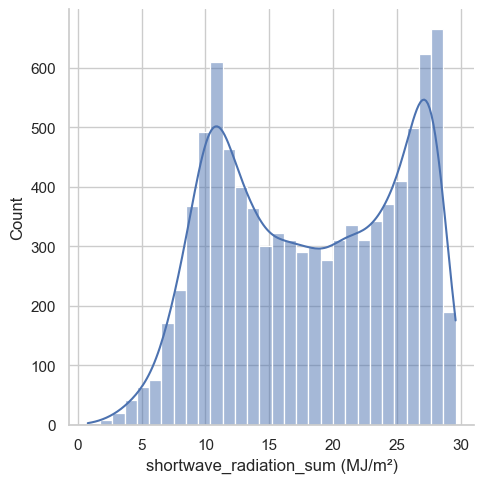

In [ ]:
# Affiche la distribution de shortwave_radiation_sum (MJ/m²)
# Permet de visualiser la forme de la répartition et détecter d’éventuelles asymétries
sns.displot(df["shortwave_radiation_sum (MJ/m²)"], kde=True, bins=30)

<Axes: ylabel='shortwave_radiation_sum (MJ/m²)'>

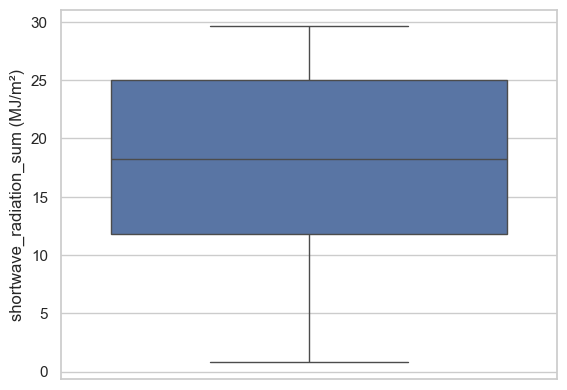

In [ ]:
# Affiche un boxplot (boîte à moustaches) de shortwave_radiation_sum (MJ/m²)
# Utile pour voir la médiane, la dispersion et les valeurs extrêmes (outliers)
sns.boxplot(df["shortwave_radiation_sum (MJ/m²)"])

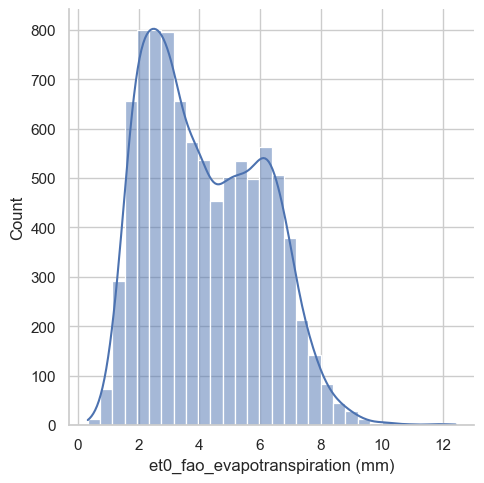

In [ ]:
# Affiche la distribution de et0_fao_evapotranspiration (mm)
# Permet de visualiser la forme de la répartition et détecter d’éventuelles asymétries
sns.displot(df["et0_fao_evapotranspiration (mm)"], kde=True, bins=30)

<Axes: ylabel='et0_fao_evapotranspiration (mm)'>

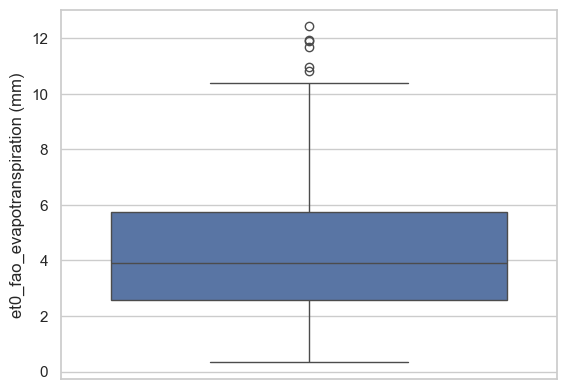

In [ ]:
# Affiche un boxplot (boîte à moustaches) de et0_fao_evapotranspiration (mm)
# Utile pour voir la médiane, la dispersion et les valeurs extrêmes (outliers)
sns.boxplot(df["et0_fao_evapotranspiration (mm)"])

* 3 - Analyse bivariée

*  Corrélation entre variables numériques :

* L’analyse bivariée entre chaque variable numérique et la variable cible (weather_code)

<Axes: title={'center': 'temperature_2m_mean (°C)'}, xlabel='weather_code (wmo code)'>

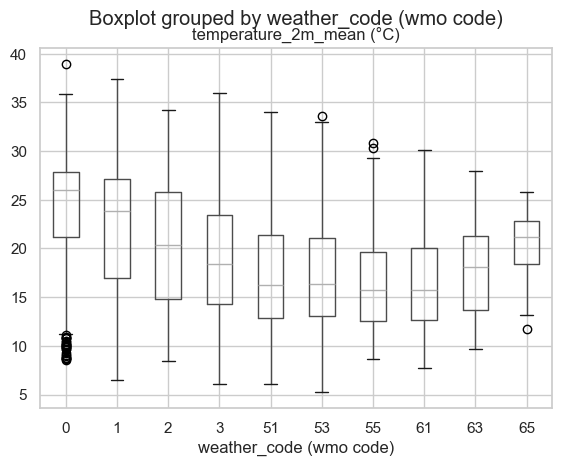

In [ ]:
# But principal : comprendre comment la température varie selon le type de météo (weather_code)
# Analyse visuelle de la distribution des températures moyennes en fonction des différents types de météo
# Cela permet d'observer comment la température varie selon les codes météo (ciel clair, pluie, neige, etc.)
# temperature_2m_mean (°C) et weather_code (wmo code)
df.boxplot(column='temperature_2m_mean (°C)',by="weather_code (wmo code)" )

<Axes: title={'center': 'relative_humidity_2m_mean (%)'}, xlabel='weather_code (wmo code)'>

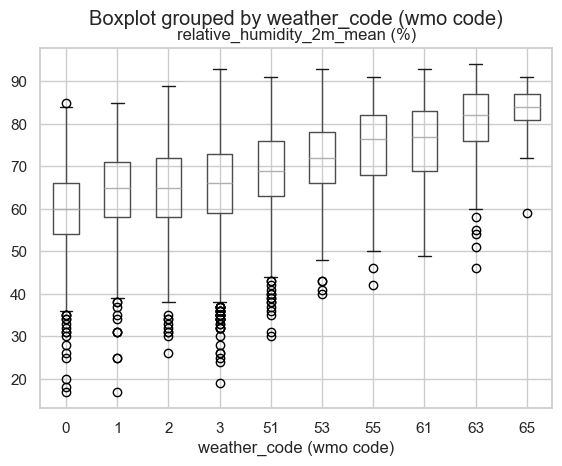

In [ ]:
# Affiche un boxplot pour visualiser la répartition de l'humidité relative moyenne en fonction des types de météo (weather_code)
df.boxplot(column='relative_humidity_2m_mean (%)', by='weather_code (wmo code)')


<Axes: title={'center': 'cloud_cover_mean (%)'}, xlabel='weather_code (wmo code)'>

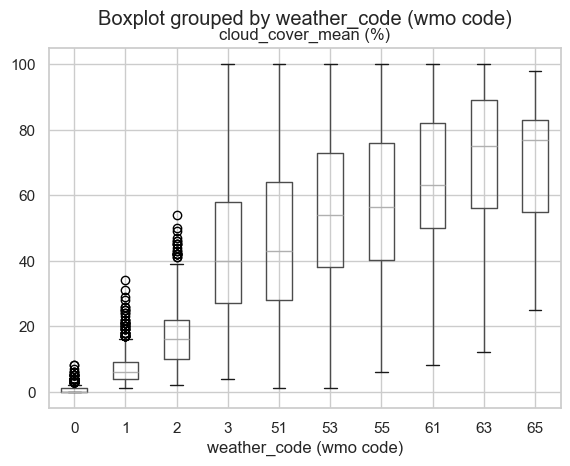

In [ ]:
# Affiche un boxplot de la couverture nuageuse moyenne en fonction des codes météo
df.boxplot(column='cloud_cover_mean (%)', by='weather_code (wmo code)')

<Axes: title={'center': 'wind_speed_10m_max (km/h)'}, xlabel='weather_code (wmo code)'>

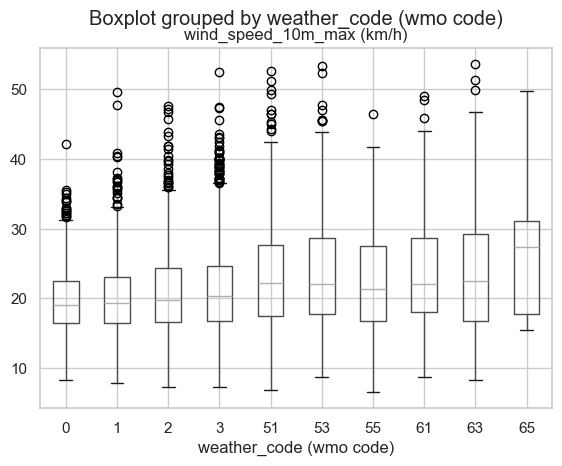

In [ ]:
df.boxplot(column='wind_speed_10m_max (km/h)', by='weather_code (wmo code)')

<Axes: title={'center': 'rain_sum (mm)'}, xlabel='weather_code (wmo code)'>

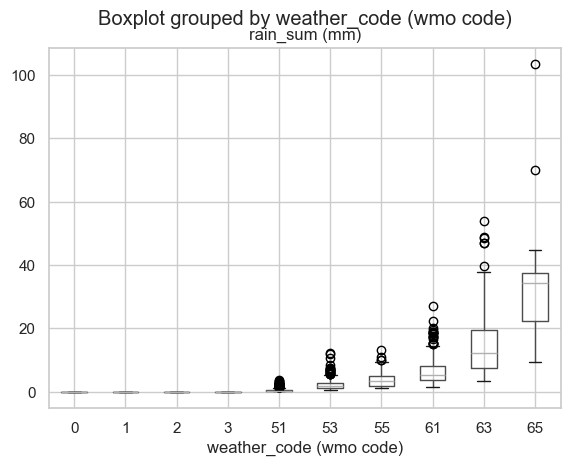

In [ ]:
df.boxplot(column='rain_sum (mm)', by='weather_code (wmo code)')

<Axes: title={'center': 'pressure_msl_mean (hPa)'}, xlabel='weather_code (wmo code)'>

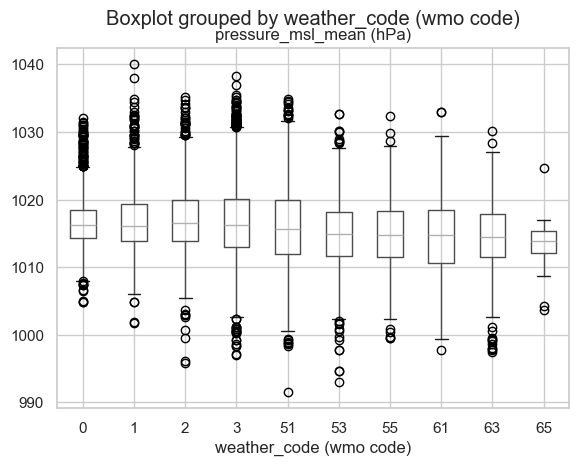

In [ ]:
df.boxplot(column='pressure_msl_mean (hPa)', by='weather_code (wmo code)')

<Axes: title={'center': 'soil_moisture_0_to_7cm_mean (m³/m³)'}, xlabel='weather_code (wmo code)'>

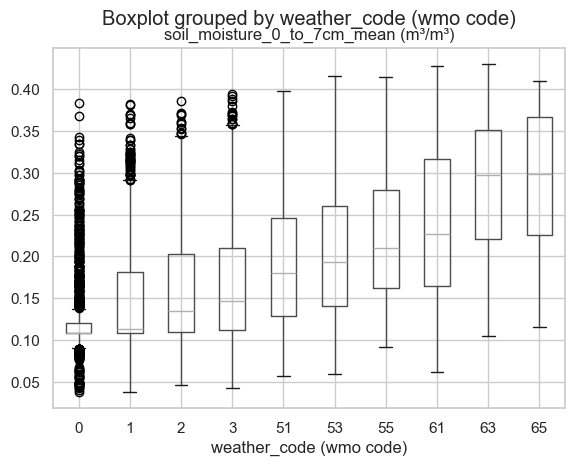

In [ ]:
df.boxplot(column='soil_moisture_0_to_7cm_mean (m³/m³)', by='weather_code (wmo code)')

<Axes: title={'center': 'shortwave_radiation_sum (MJ/m²)'}, xlabel='weather_code (wmo code)'>

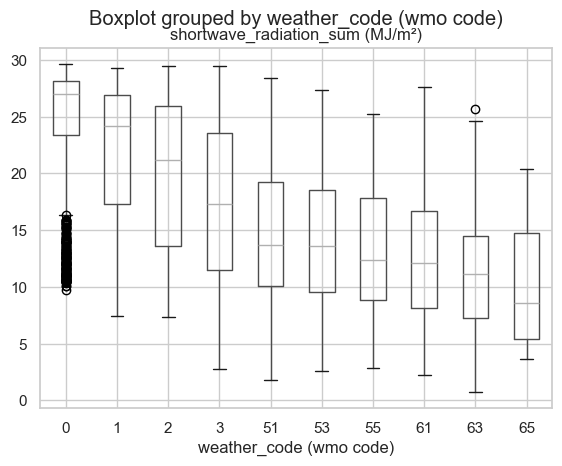

In [ ]:
df.boxplot(column='shortwave_radiation_sum (MJ/m²)', by='weather_code (wmo code)')

<Axes: title={'center': 'et0_fao_evapotranspiration (mm)'}, xlabel='weather_code (wmo code)'>

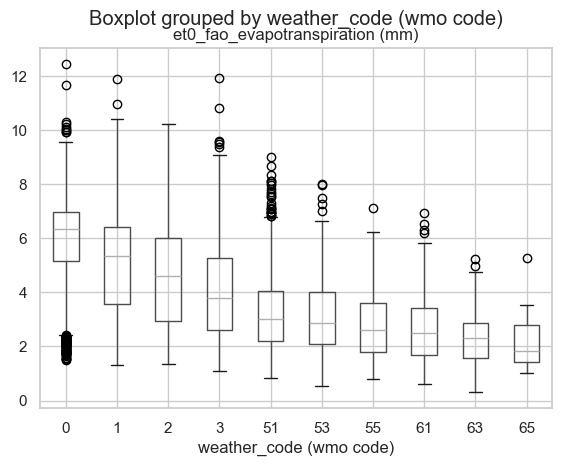

In [ ]:
df.boxplot(column='et0_fao_evapotranspiration (mm)', by='weather_code (wmo code)')

* L’analyse bivariée des variables numériques explicatives

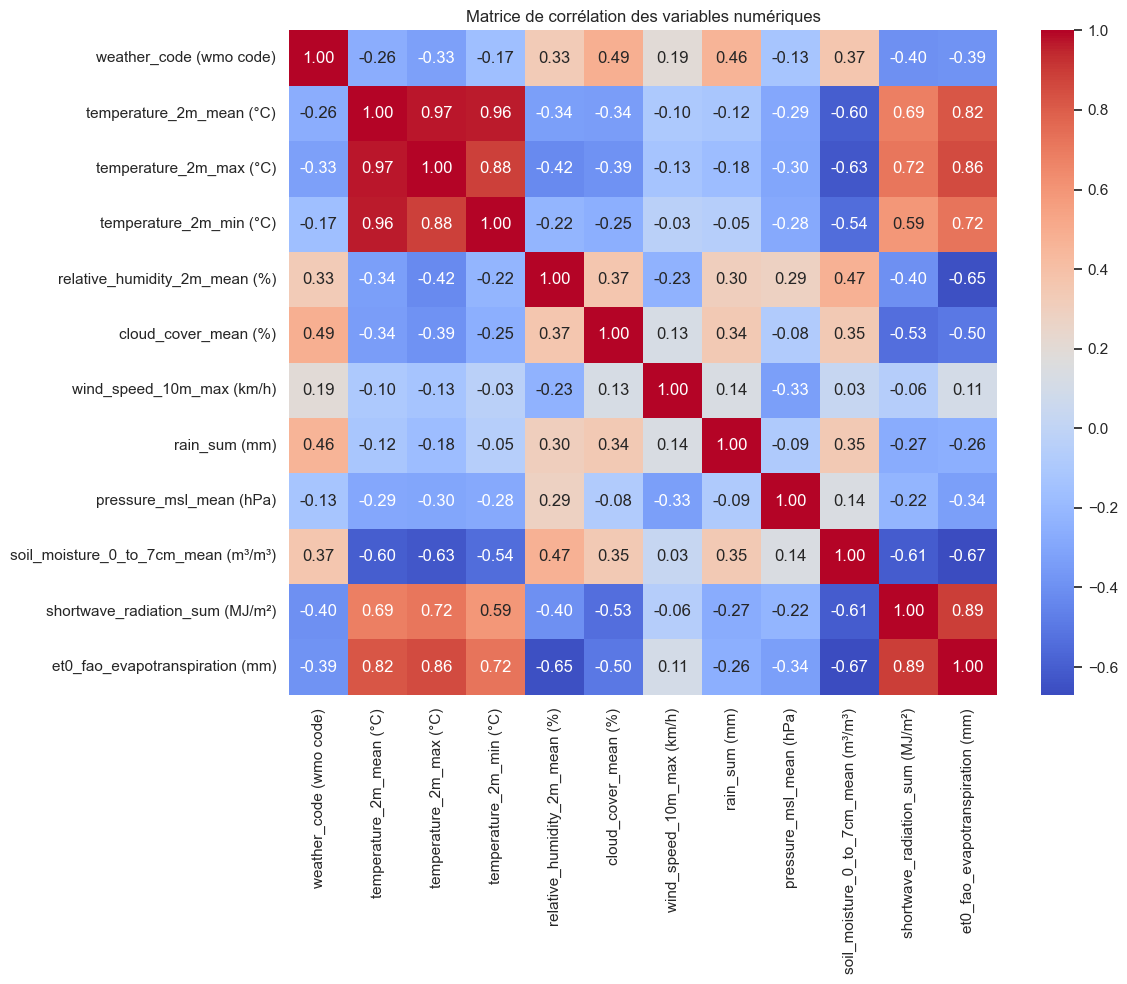

In [ ]:
# Affiche la matrice de corrélation entre les variables numériques
# Utile pour repérer les relations linéaires fortes (positives ou négatives) entre variables
plt.figure(figsize=(12, 10))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation des variables numériques")
plt.tight_layout()
plt.show()

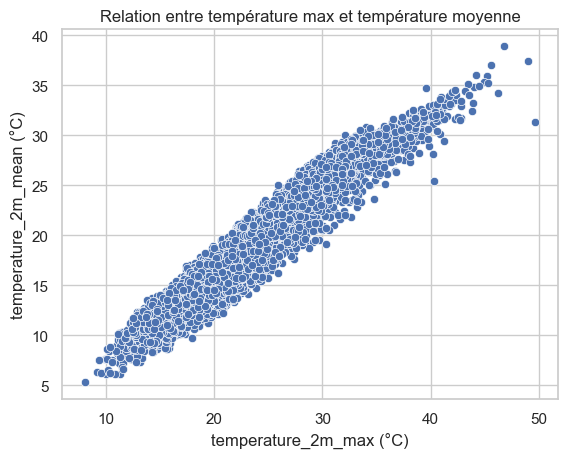

In [ ]:
# deux variables fortement corrélées température moyenne et maximale
sns.scatterplot(x='temperature_2m_max (°C)', y='temperature_2m_mean (°C)', data=df)
plt.title("Relation entre température max et température moyenne")
plt.show()


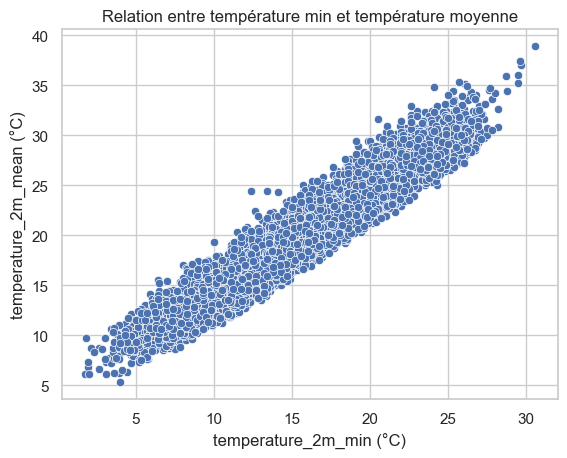

In [ ]:
sns.scatterplot(x='temperature_2m_min (°C)', y='temperature_2m_mean (°C)', data=df)
plt.title("Relation entre température min et température moyenne")
plt.show()


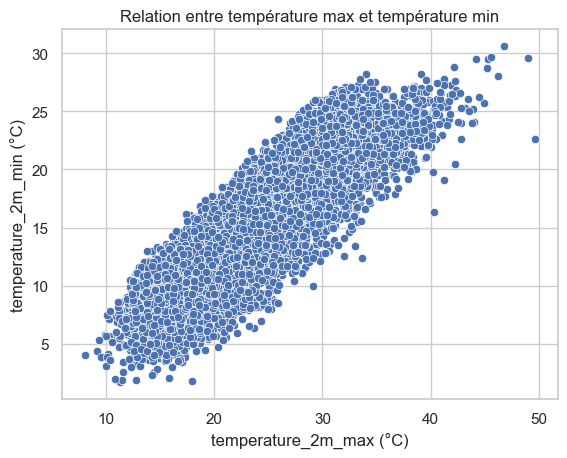

In [ ]:
sns.scatterplot(x='temperature_2m_max (°C)', y='temperature_2m_min (°C)', data=df)
plt.title("Relation entre température max et température min")
plt.show()


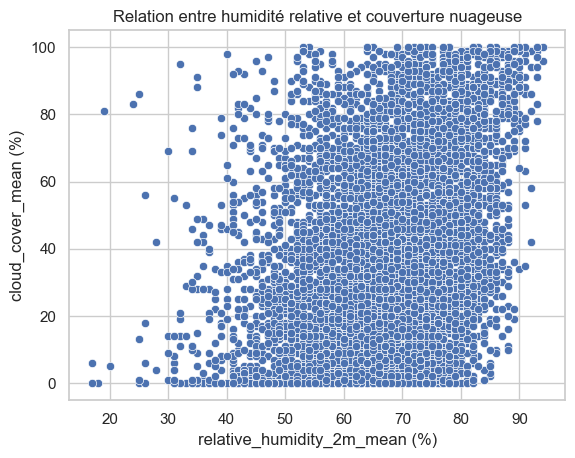

In [ ]:
sns.scatterplot(x='relative_humidity_2m_mean (%)', y='cloud_cover_mean (%)', data=df)
plt.title("Relation entre humidité relative et couverture nuageuse")
plt.show()


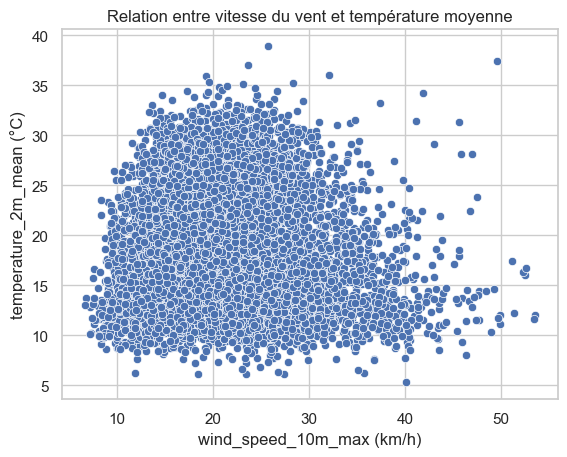

In [ ]:
sns.scatterplot(x='wind_speed_10m_max (km/h)', y='temperature_2m_mean (°C)', data=df)
plt.title("Relation entre vitesse du vent et température moyenne")
plt.show()


temperature_2m_mean (°C) vs temperature_2m_max (°C) → corrélation = 0.97


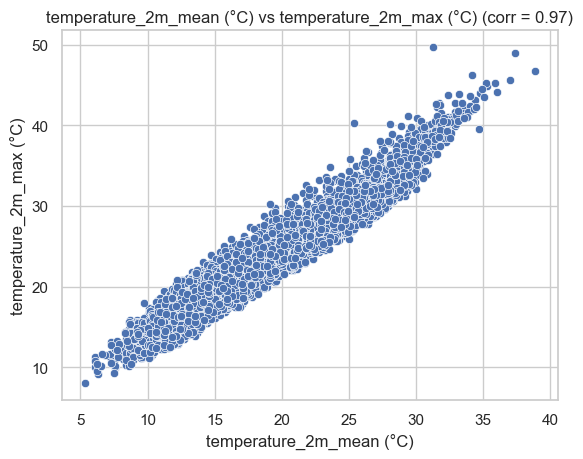

temperature_2m_mean (°C) vs temperature_2m_min (°C) → corrélation = 0.96


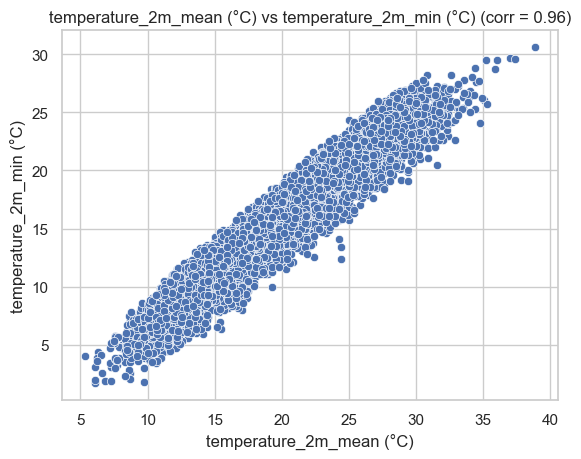

temperature_2m_mean (°C) vs et0_fao_evapotranspiration (mm) → corrélation = 0.82


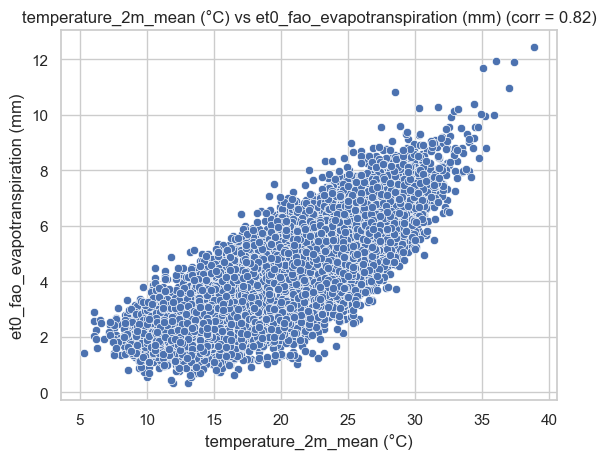

temperature_2m_max (°C) vs temperature_2m_min (°C) → corrélation = 0.88


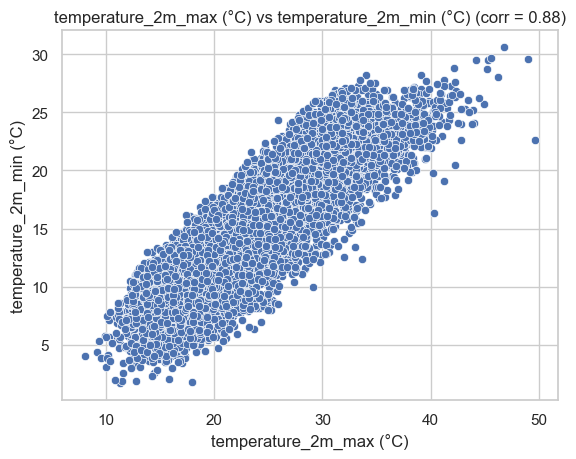

temperature_2m_max (°C) vs et0_fao_evapotranspiration (mm) → corrélation = 0.86


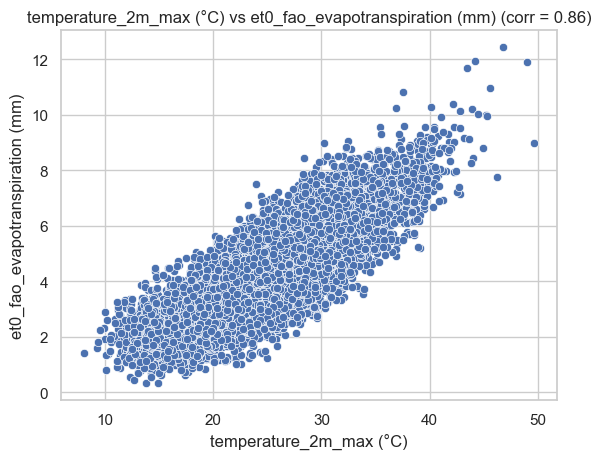

shortwave_radiation_sum (MJ/m²) vs et0_fao_evapotranspiration (mm) → corrélation = 0.89


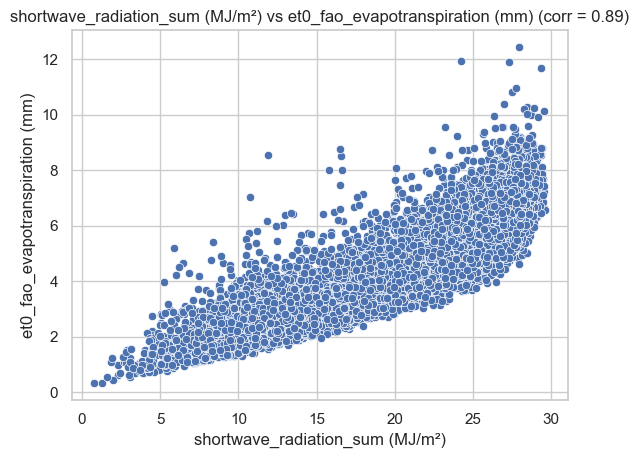

In [ ]:
# Script automatique pour détecter les relations fortes
import itertools

# Récupérer uniquement les colonnes numériques
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Afficher les relations avec une forte corrélation (ex : > 0.8)
for var1, var2 in itertools.combinations(numeric_cols, 2):
    corr_value = corr_matrix.loc[var1, var2]
    if abs(corr_value) > 0.8:
        print(f"{var1} vs {var2} → corrélation = {corr_value:.2f}")
        sns.scatterplot(x=var1, y=var2, data=df)
        plt.title(f"{var1} vs {var2} (corr = {corr_value:.2f})")
        plt.show()


*  Relations numériques vs catégorielles :

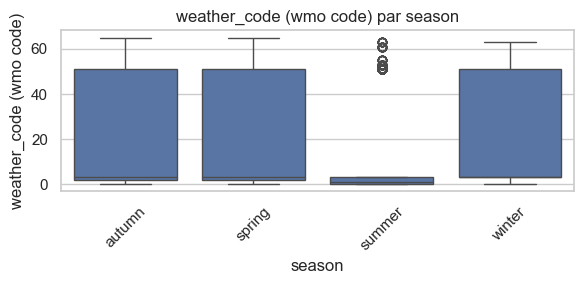

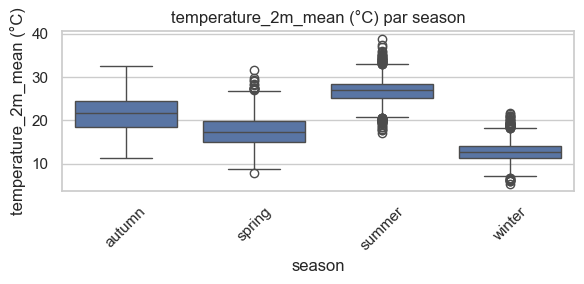

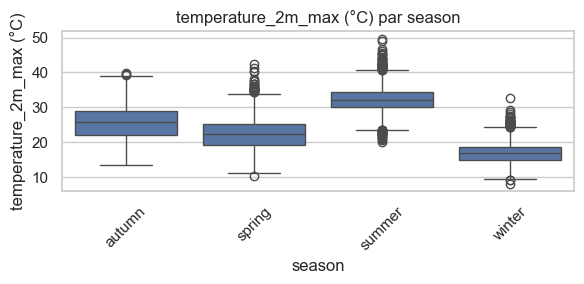

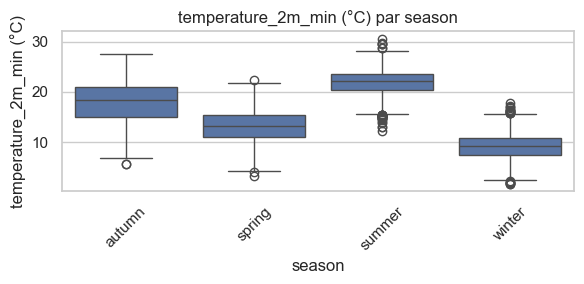

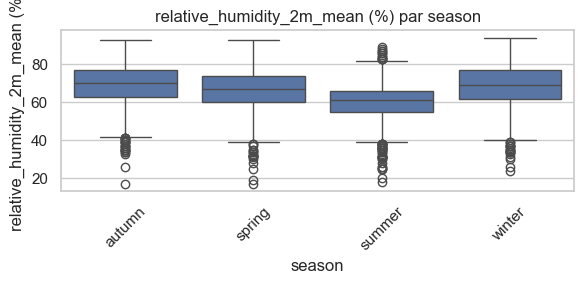

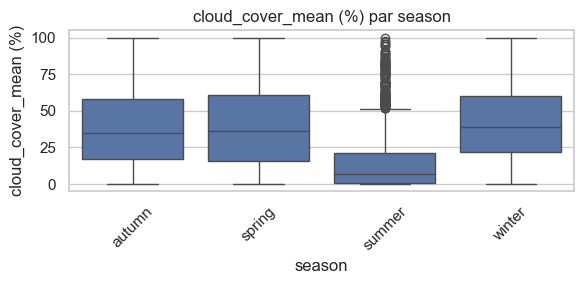

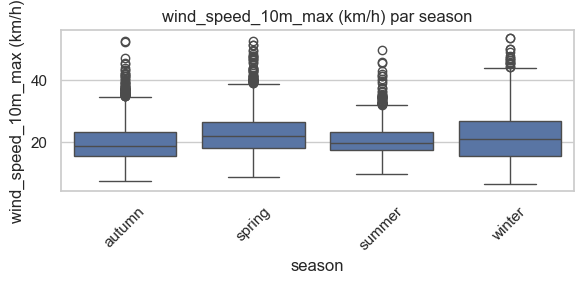

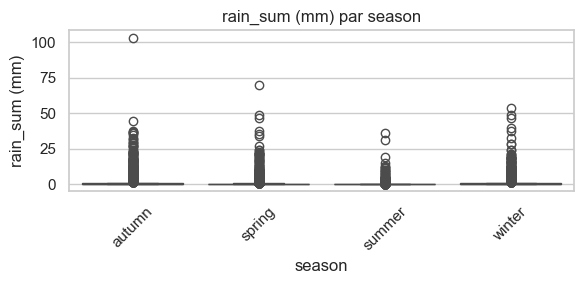

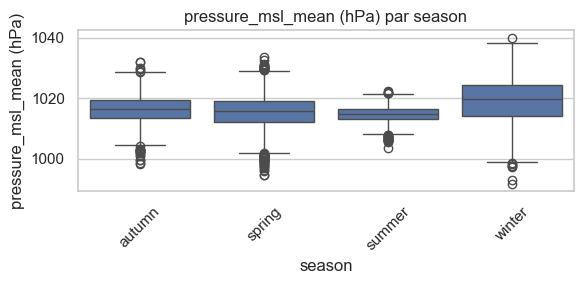

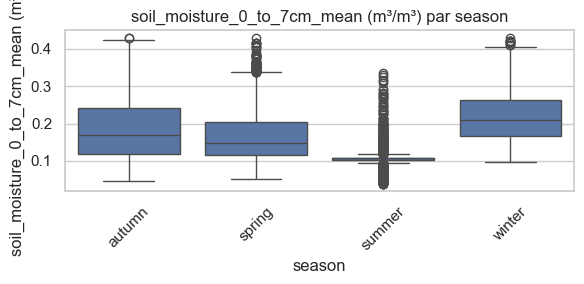

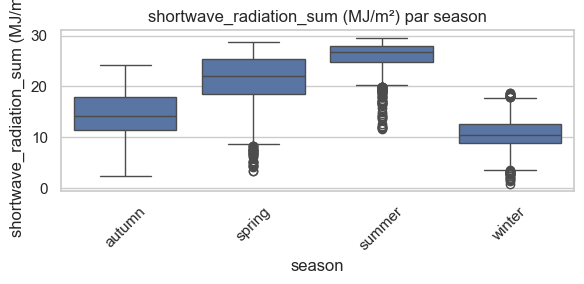

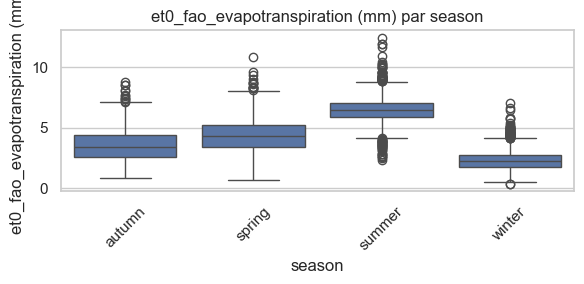

In [ ]:
# Affiche des boxplots pour analyser la distribution des variables numériques
# selon les différentes catégories de la variable 'season'
# Permet de détecter les différences de tendance centrale et de dispersion entre les saisons
categorical_cols = ['season']

for cat_col in categorical_cols:
    for num_col in numeric_cols:
        plt.figure(figsize=(6, 3))
        sns.boxplot(x=cat_col, y=num_col, data=df)
        plt.title(f"{num_col} par {cat_col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

* Rééchantillonnage

# **Detecting and Handling Outliers**

**Detecting**

Columns with detected outliers :
- relative_humidity_2m_mean (%): 0.05% of outliers
- wind_speed_10m_max (km/h): 0.25% of outliers
- rain_sum (mm): 9.51% of outliers
- pressure_msl_mean (hPa): 0.08% of outliers


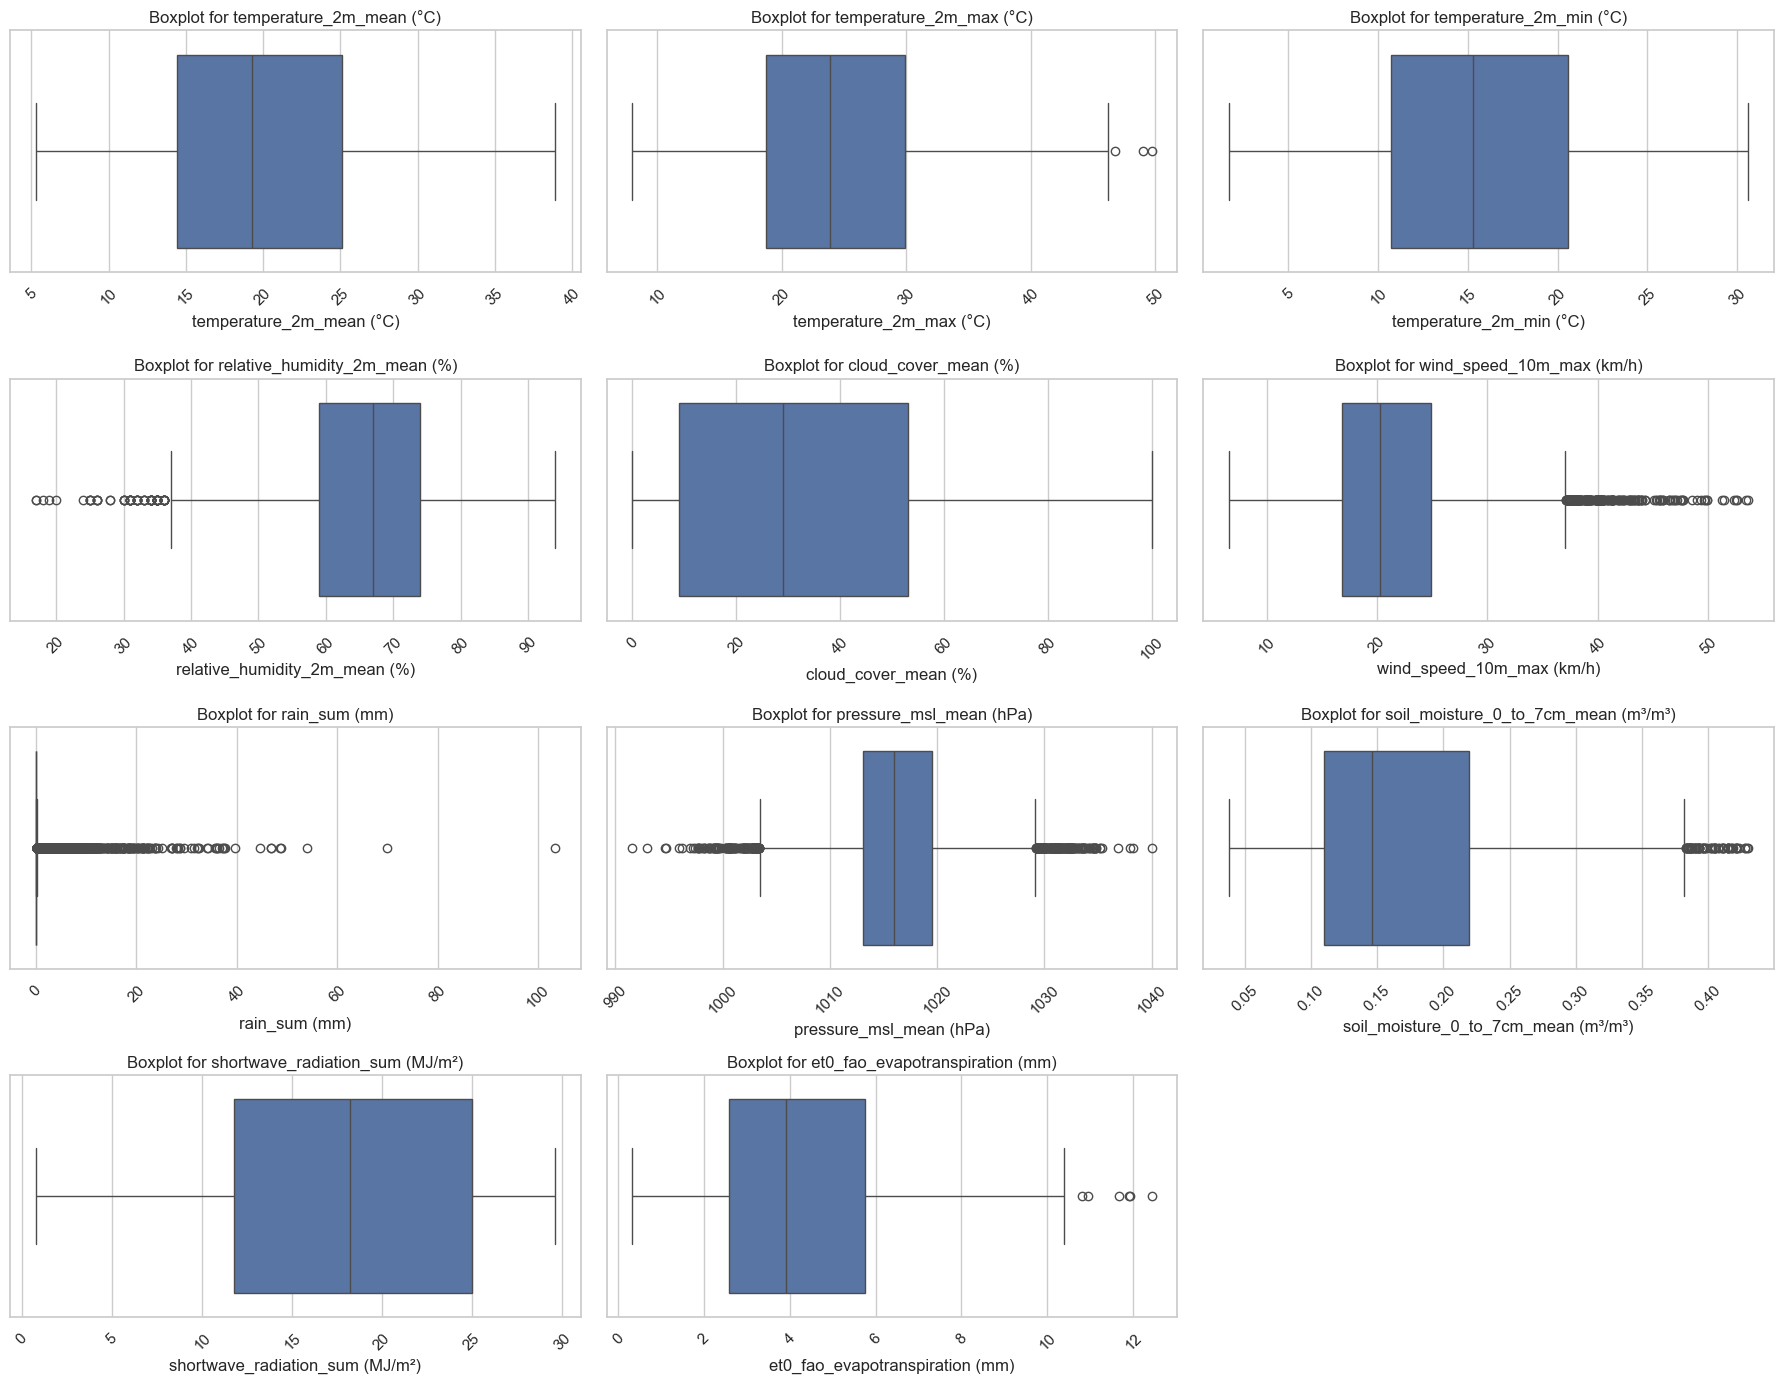

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd

# Exculded columns:
exclude_columns = ['weather_code (wmo code)', 'date', 'day', 'month', 'year', 'season']

columns_to_check = [col for col in df.columns if col not in exclude_columns and pd.api.types.is_numeric_dtype(df[col])]

# Initialise the lists to stock the results in them
columns_with_outliers = []
outlier_percentage = {}

# Subplots disposition
num_columns = len(columns_to_check)
num_rows = math.ceil(num_columns / 3)

# Creation of boxplots
plt.figure(figsize=(18, 14))

for i, column_name in enumerate(columns_to_check, 1):
    # Count the IQR bounds
    Q1 = df[column_name].quantile(0.15)
    Q3 = df[column_name].quantile(0.85)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detect the outliers
    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage[column_name] = (outlier_count / len(df[column_name])) * 100

    # Add the column to the list if there is outliers detected within it
    if outlier_count > 0:
        columns_with_outliers.append(column_name)

    # creat the boxplot of the column
    plt.subplot(num_rows, 3, i)
    sns.boxplot(data=df, x=column_name)
    plt.title(f'Boxplot for {column_name}')
    plt.xticks(rotation=45)

# Display the results
if columns_with_outliers:
    print("Columns with detected outliers :")
    for col in columns_with_outliers:
        print(f"- {col}: {outlier_percentage[col]:.2f}% of outliers")
else:
    print("No outliers detected")

# Afficher les boxplots
plt.tight_layout()
plt.show()


**Handling Outliers**

Imputation of Outliers using winsorisation technique

📊 Percentage of outliers before and after winsorization :
- temperature_2m_mean (°C) : Before winsorisation: 0.00% ; After winsorisation: 0.00%
- temperature_2m_max (°C) : Before winsorisation: 0.00% ; After winsorisation: 0.00%
- temperature_2m_min (°C) : Before winsorisation: 0.00% ; After winsorisation: 0.00%
- relative_humidity_2m_mean (%) : Before winsorisation: 0.05% ; After winsorisation: 0.00%
- cloud_cover_mean (%) : Before winsorisation: 0.00% ; After winsorisation: 0.00%
- wind_speed_10m_max (km/h) : Before winsorisation: 0.25% ; After winsorisation: 0.00%
- rain_sum (mm) : Before winsorisation: 9.51% ; After winsorisation: 0.00%
- pressure_msl_mean (hPa) : Before winsorisation: 0.08% ; After winsorisation: 0.00%
- soil_moisture_0_to_7cm_mean (m³/m³) : Before winsorisation: 0.00% ; After winsorisation: 0.00%
- shortwave_radiation_sum (MJ/m²) : Before winsorisation: 0.00% ; After winsorisation: 0.00%
- et0_fao_evapotranspiration (mm) : Before winsorisation: 0.00% ; After wins

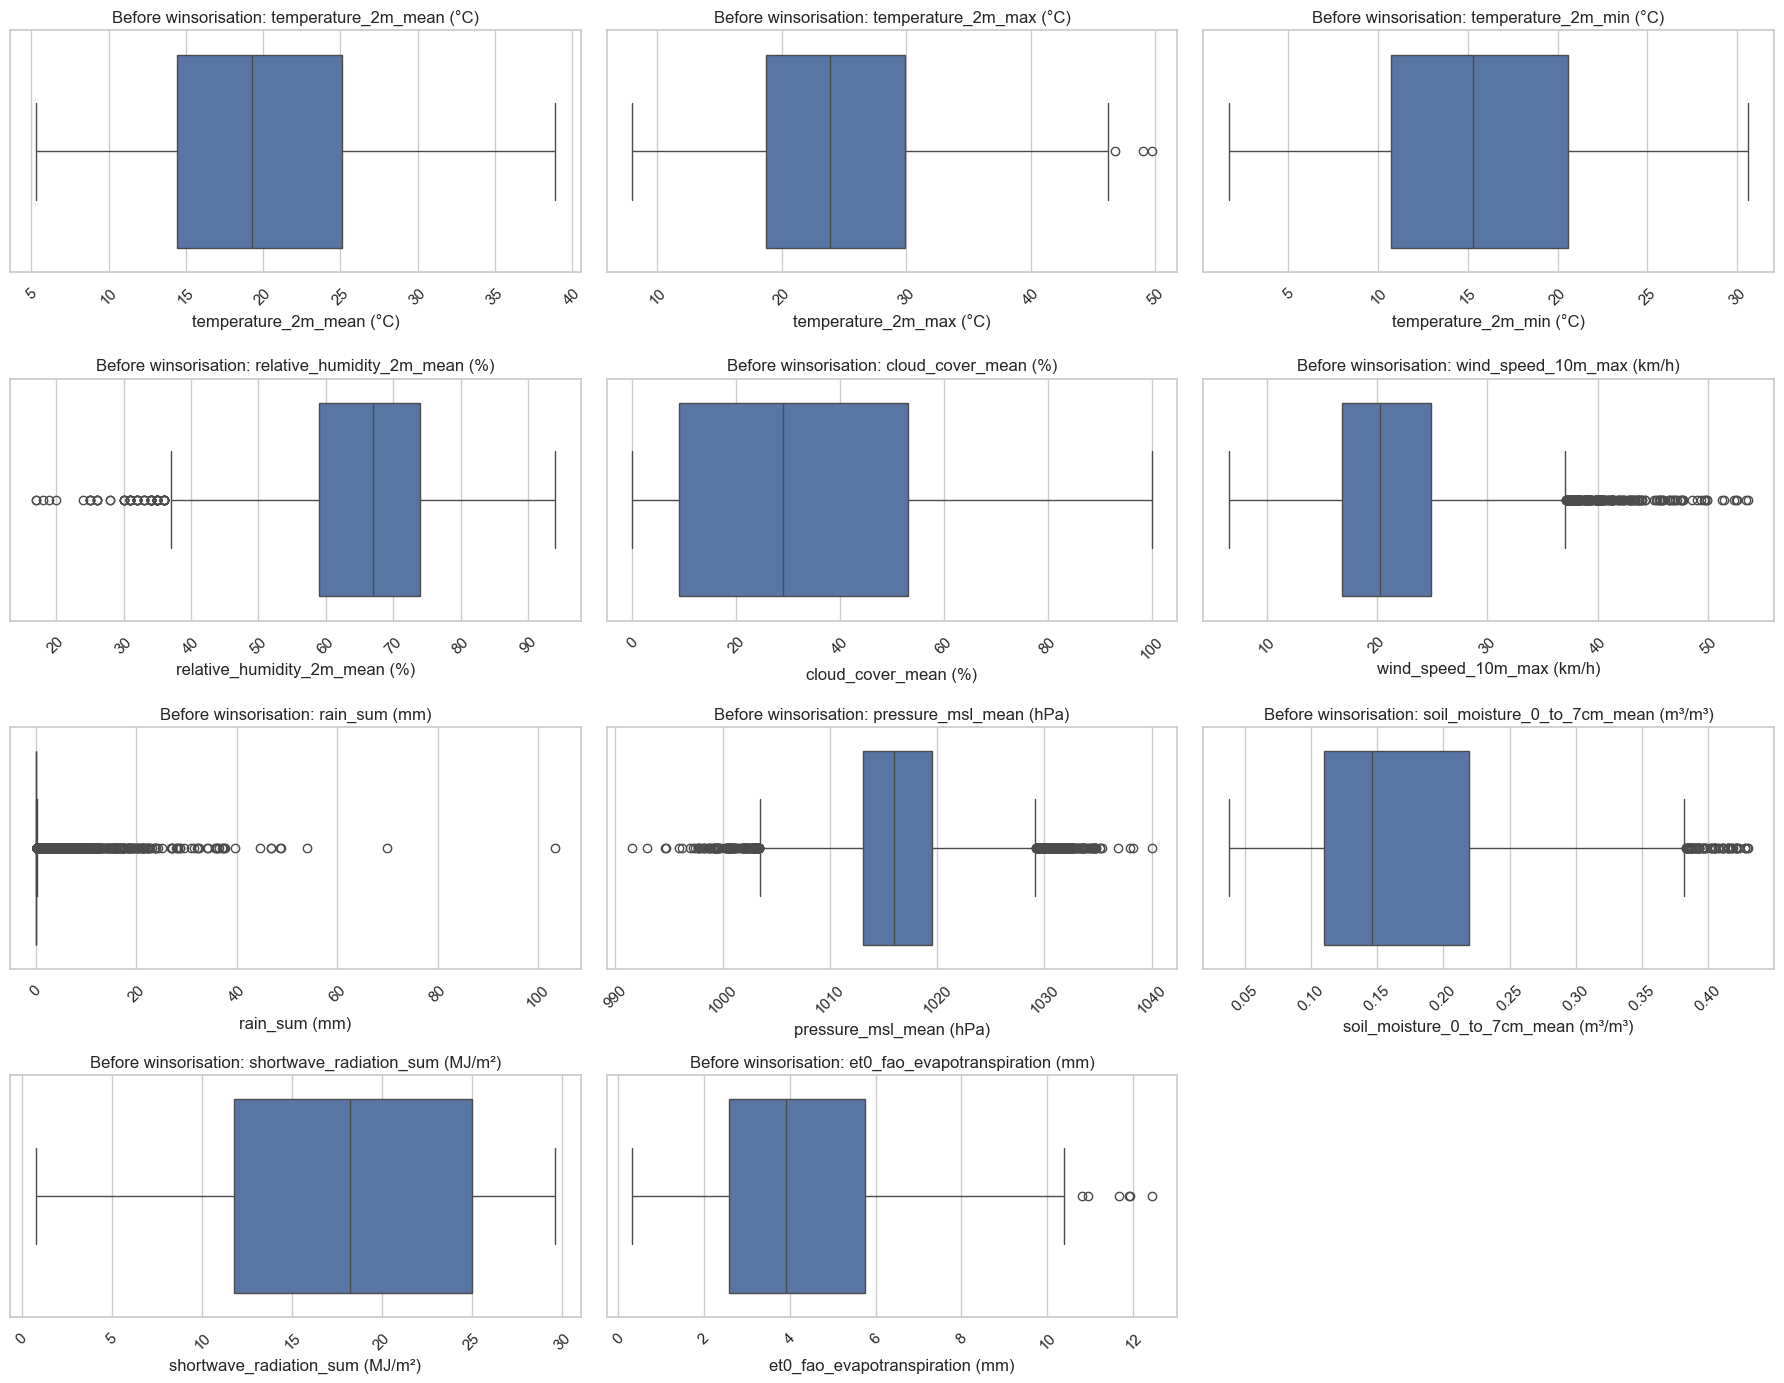

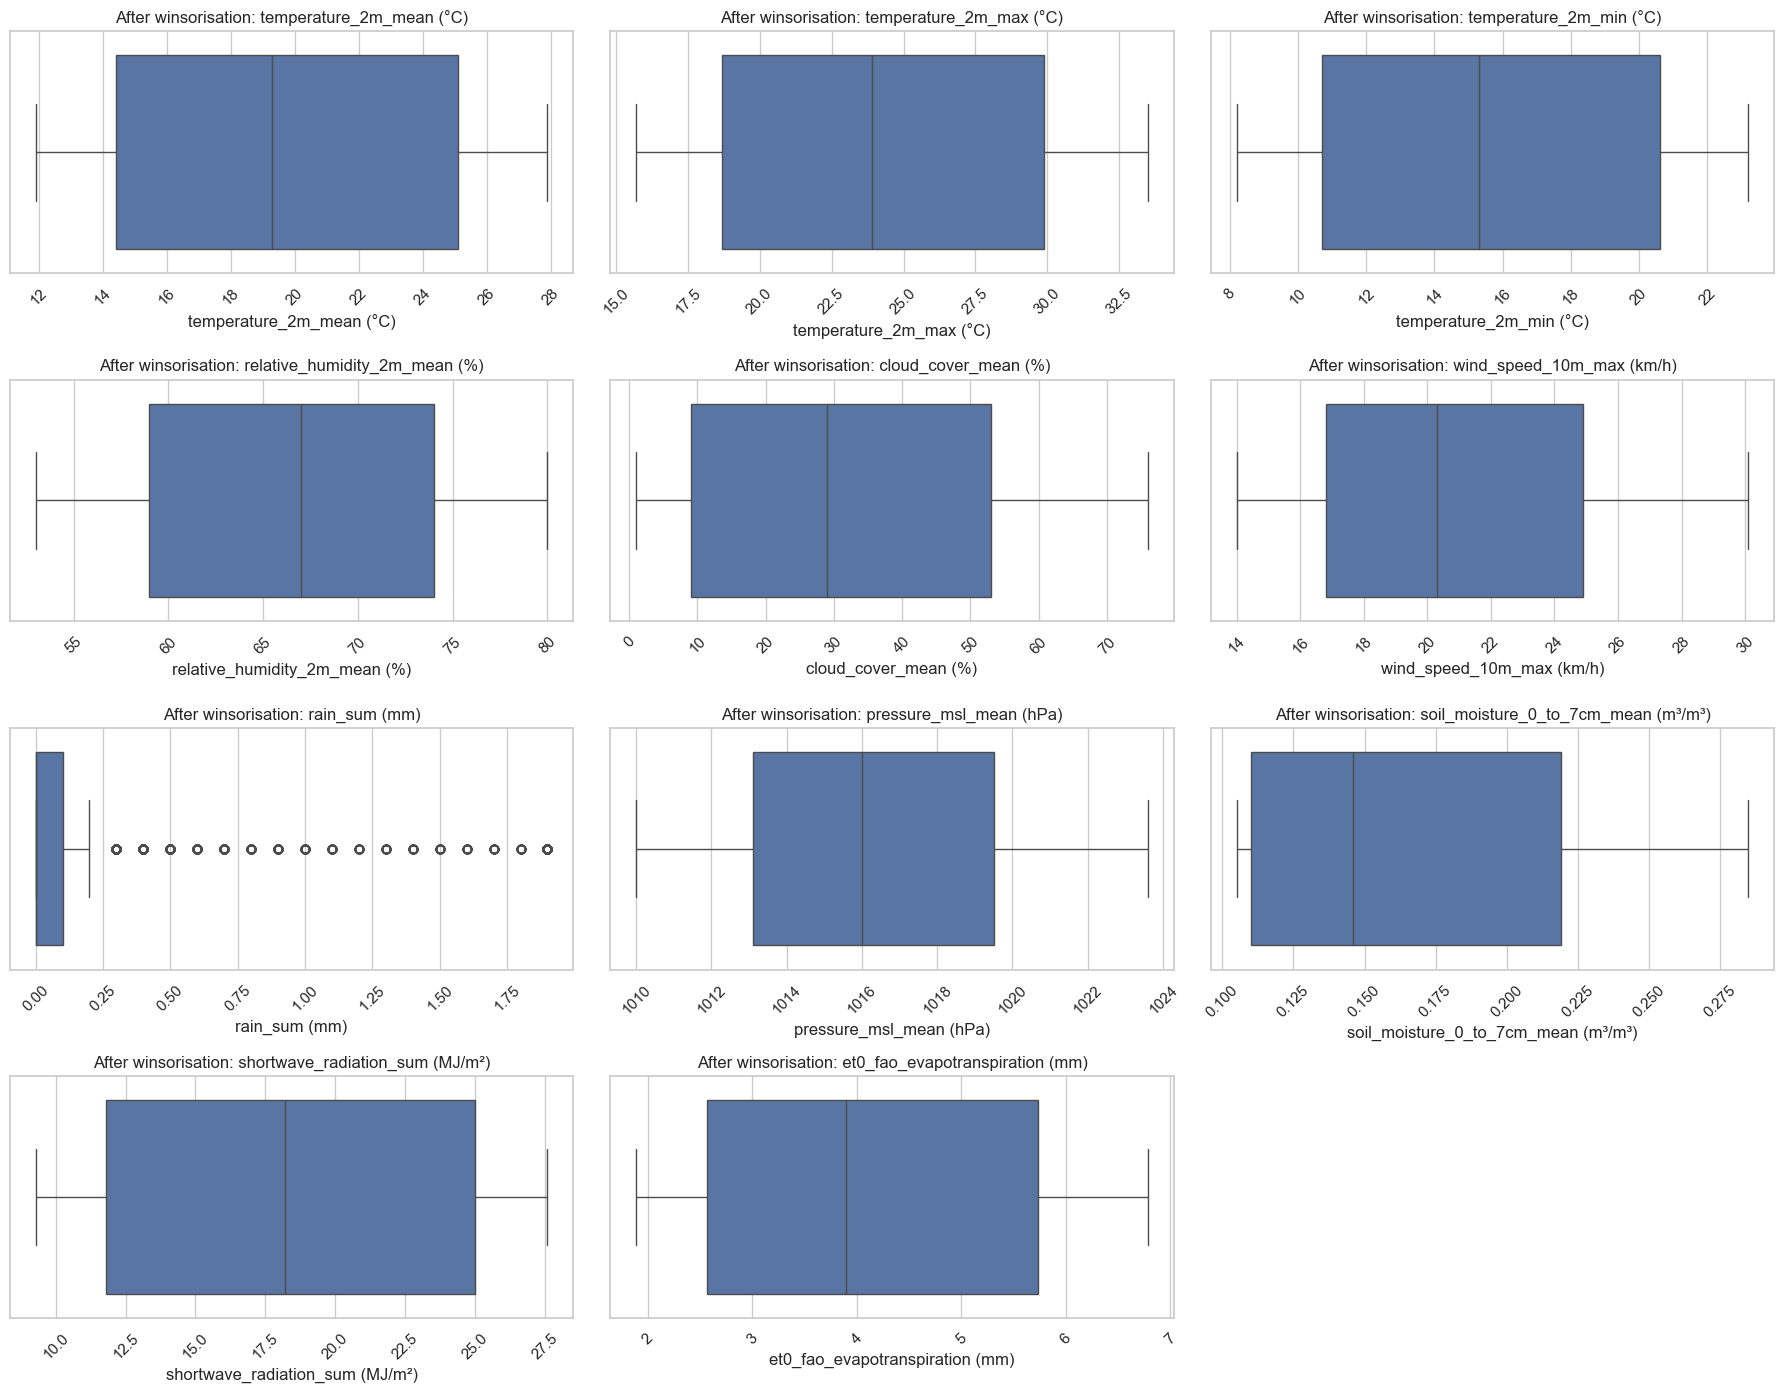

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import math

# Copy the original DataFrame
df_winsorized = df.copy()

# Define the columns to exclude
exclude_columns = ['weather_code (wmo code)', 'date', 'day', 'month', 'year', 'season']

# Select the numerical columns to check
columns_to_check = [col for col in df.columns if col not in exclude_columns and pd.api.types.is_numeric_dtype(df[col])]

# Winsorization function that will limit extreme values to the specified percentiles
def winsorize_series(s, lower_quantile=0.1, upper_quantile=0.9):
    lower = s.quantile(lower_quantile)
    upper = s.quantile(upper_quantile)
    return s.clip(lower=lower, upper=upper)

# Dictionaries to store the percentages of outliers before and after processing
outlier_percentage_before = {}
outlier_percentage_after = {}

# 📌 Apply winsorization to each column
for column in columns_to_check:
    column_data = df_winsorized[column]

    # Calculation of the bounds using the IQR method
    Q1 = column_data.quantile(0.15)
    Q3 = column_data.quantile(0.85)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detect outliers in the original data
    outliers_before = column_data[(column_data < lower_bound) | (column_data > upper_bound)]
    outlier_percentage_before[column] = (len(outliers_before) / len(column_data)) * 100

    # Apply winsorization
    df_winsorized[column] = winsorize_series(column_data, lower_quantile=0.1, upper_quantile=0.9)

    # Detect outliers after winsorization
    column_data_modified = df_winsorized[column]
    Q1_mod = column_data_modified.quantile(0.15)
    Q3_mod = column_data_modified.quantile(0.85)
    IQR_mod = Q3_mod - Q1_mod
    lower_bound_mod = Q1_mod - 1.5 * IQR_mod
    upper_bound_mod = Q3_mod + 1.5 * IQR_mod

    outliers_after = column_data_modified[(column_data_modified < lower_bound_mod) | (column_data_modified > upper_bound_mod)]
    outlier_percentage_after[column] = (len(outliers_after) / len(column_data_modified)) * 100

# Display the percentages of outliers before and after processing
print("📊 Percentage of outliers before and after winsorization :")
for column in columns_to_check:
    print(f"- {column} : Before winsorisation: {outlier_percentage_before[column]:.2f}% ; After winsorisation: {outlier_percentage_after[column]:.2f}%")

# 📌 Display the boxplots before winsorization
plt.figure(figsize=(18, 14))
num_columns = len(columns_to_check)
num_rows = math.ceil(num_columns / 3)

for i, column in enumerate(columns_to_check, 1):
    plt.subplot(num_rows, 3, i)
    sns.boxplot(data=df, x=column)
    plt.title(f'Before winsorisation: {column}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 📌 Display the boxplots after winsorization
plt.figure(figsize=(18, 14))
for i, column in enumerate(columns_to_check, 1):
    plt.subplot(num_rows, 3, i)
    sns.boxplot(data=df_winsorized, x=column)
    plt.title(f'After winsorisation: {column}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
df_winsorized.to_csv("final_dataset_version1.csv" ,index = False )

We should drop the temperature_2m_mean (°C) feature because it's highly correlated with the temperature_2m_max (°C) and the temperature_2m_min (°C) ( > 90% )

In [ ]:
df_winsorized.drop(columns="temperature_2m_mean (°C)", inplace=True)

In [ ]:
df_winsorized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9163 entries, 0 to 9162
Data columns (total 16 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   time                                 9163 non-null   datetime64[ns]
 1   year                                 9163 non-null   int32         
 2   month                                9163 non-null   int32         
 3   day                                  9163 non-null   int32         
 4   season                               9163 non-null   category      
 5   weather_code (wmo code)              9163 non-null   int64         
 6   temperature_2m_max (°C)              9163 non-null   float64       
 7   temperature_2m_min (°C)              9163 non-null   float64       
 8   relative_humidity_2m_mean (%)        9163 non-null   int64         
 9   cloud_cover_mean (%)                 9163 non-null   int64         
 10  wind_speed_1

**Handling the Target class Imbalance ( weather_code (wmo code) )**

The idea is combaining the minorated classes into one class

Light drizzle (51), Moderate drizzle (53), heavy drizzle (55) ==== drizzle

Light rain (61), Moderate rain (63), heavy rain (65) ==== rain

Now we have six labels in the target variable instead of ten variables:

Partly cloudy : 2

Cloudy : 3

Mainly clear : 1

Clear sky : 0

rain : ( 61 + 63 + 65 )

drizzle : ( 51 + 53 + 55 )


**1.Mapping each code to his condition**

In [ ]:
# Create the mapping dictionary
weather_conditions = {
    0: "Clear Sky ☀️",
    1: "Mainly Clear 🌤",
    2: "Partly Cloudy ⛅",
    3: "Cloudy ☁️",
    45: "Fog 🌫",
    48: "Fog 🌫",
    51: "Light Drizzle 🌦",
    53: "Moderate Drizzle 🌧",
    55: "Heavy Drizzle 🌧",
    61: "Light Rain 🌦",
    63: "Moderate Rain 🌧",
    65: "Heavy Rain 🌧",
    71: "Light Snow ❄️",
    73: "Moderate Snow ❄️",
    75: "Heavy Snow ❄️",
    95: "Thunderstorm ⛈"
}

# Apply the mapping to create a new column
df_winsorized['weather_condition'] = df_winsorized['weather_code (wmo code)'].map(weather_conditions)


In [ ]:
# Drop the weather_code column
df_winsorized= df_winsorized.drop(columns=['weather_code (wmo code)'])

In [ ]:
df_winsorized.head()

,time,year,month,day,season,temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),wind_speed_10m_max (km/h),rain_sum (mm),pressure_msl_mean (hPa),soil_moisture_0_to_7cm_mean (m³/m³),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm),weather_condition
0,2000-01-01,2000,1,1,winter,15.70,8.20,76,43,14.80,1.90,1023.60,0.28,9.28,1.89,Light Drizzle 🌦
1,2000-01-02,2000,1,2,winter,15.70,8.20,69,37,22.90,0.30,1023.60,0.28,9.28,1.89,Light Drizzle 🌦
2,2000-01-03,2000,1,3,winter,15.70,8.20,73,36,23.20,1.90,1023.60,0.28,9.28,1.89,Moderate Drizzle 🌧
3,2000-01-04,2000,1,4,winter,15.70,8.40,62,47,16.10,0.00,1023.60,0.28,9.28,1.96,Cloudy ☁️
4,2000-01-05,2000,1,5,winter,15.70,8.20,78,39,14.00,0.00,1023.60,0.28,11.06,1.89,Partly Cloudy ⛅


**2. Combine/merge target classes → new column main_weather_condition**

In [ ]:
# Define the main_weather mapping
main_weather_mapping = {
    'Light Drizzle 🌦': 'Drizzle',
    'Moderate Drizzle 🌧': 'Drizzle',
    'Heavy Drizzle 🌧': 'Drizzle',
    'Light Rain 🌦': 'Rain',
    'Moderate Rain 🌧': 'Rain',
    'Heavy Rain 🌧': 'Rain',
    'Cloudy ☁️': 'Cloudy',
    'Partly Cloudy ⛅': 'Partly Cloudy',
    'Mainly Clear 🌤': 'Mainly Clear',
    'Clear Sky ☀️': 'Clear Sky'
}

# Define the intensity mapping
def get_intensity(condition):
    if 'Light' in condition:
        return 'light'
    elif 'Moderate' in condition:
        return 'moderate'
    elif 'Heavy' in condition:
        return 'heavy'
    else:
        return 'none'

# Apply mappings
df_winsorized['intensity'] = df_winsorized['weather_condition'].apply(get_intensity)
df_winsorized['weather_condition'] = df_winsorized['weather_condition'].map(main_weather_mapping)


**3.Visualizing the new distribution of the target variable**

Main Weather Counts:
Cloudy: 3363
Drizzle: 2009
Clear Sky: 1250
Partly Cloudy: 1033
Mainly Clear: 959
Rain: 549


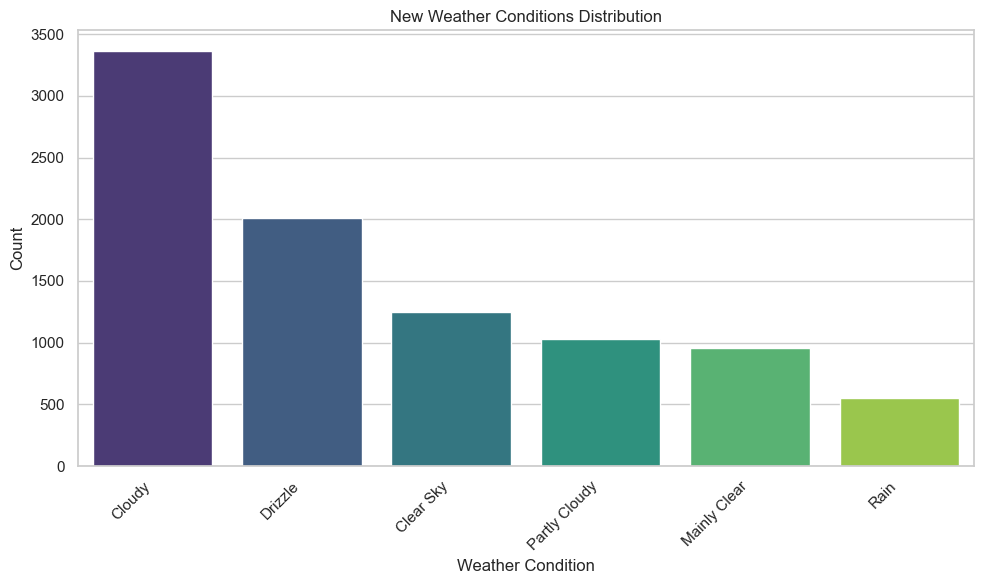

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

weather_counts = df_winsorized['weather_condition'].value_counts()
print("Main Weather Counts:")
for condition, count in weather_counts.items():
    print(f'{condition}: {count}')


plt.figure(figsize=(10, 6))
sns.countplot(data=df_winsorized, x='weather_condition', order=df_winsorized['weather_condition'].value_counts().index, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title('New Weather Conditions Distribution')
plt.xlabel('Weather Condition')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [ ]:
df_winsorized.to_csv("final_dataset_version2.csv", index=False)

Now if we apply undersampling on the dataset we won't lose a lot of data ( we will have around 3000 row )

If we are planning to use the **intense** variable we should encode it before the target variable **weather_condition**

**UPCOMING STEPS**

1. First, Encode the **intense** variable if you are planning to use it to predict the target

2. Second, Encode the **weather_condition** variable ( Target variable )

3. Third, Define the X, and y variable ( y : Target variable, X : all the other variable ( you can exclude the date, month, year, day, and season))

4. Forth, Apply undersampling to the X, and y

5. Fifth, Split the undersampled data into train, validation, and test sets

6. Sixth, Scale the data ( apply fit_transform to X_train, and transform to X_val, and X_test)

7. Seventh, Reshape your data for the model

8. Finally, Run you model, evaluate it

Note that, I saved the final dataset under the name " final_dataset_version2.csv " , you should upload it first

### Étape 5 – Préparation des données pour la modélisation

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['season'] = le.fit_transform(df['season'])


In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('weather_code (wmo code)')
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['weather_code (wmo code)'])
y = df['weather_code (wmo code)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')
df = df.set_index('time')  # utile pour ARIMA/LSTM

In [ ]:
print(pd.infer_freq(df.index))

D


In [ ]:
# Vérifier la stationnarité (ARIMA)
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on the correct target variable column
filtred_df = df.diff(12).dropna()
result = adfuller(filtred_df['weather_code (wmo code)'])

print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

ADF Statistic: -20.90291354414021
p-value: 0.0


In [ ]:
# Pour LSTM
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['weather_code (wmo code)']])


### Etape 5 :  Feature Engineering (Création de variables)
Création de nouvelles variables utiles à partir des existantes (ex : étiquettes de risque à partir de weathercode)

Transformation de dates (mois, saisons, etc.)

Normalisation / standardisation si besoin+ oversampling or undersampling

### Etape 6 : Préparation pour Modélisation
Séparer X (features) et y (cible)

Encodage si besoin (OneHot, Label)

Scaling (StandardScaler ou MinMaxScaler)

Création du pipeline de transformation

### Etape 7 : Modélisation
Choix du modèle :(XGBoost, ARIMA, LSTM pour séries temporelles…)

Entraînement / test

Cross-validation

Sauvegarde du modèle (joblib, pickle)

🔹 8. Évaluation
Matrice de confusion

Accuracy, F1-score, Recall, AUC…

Analyse des erreurs

🔹 9. Visualisation & Tableau de Bord (Dash ou Streamlit)
Affichage des prévisions et risques

Courbes météo, filtres par date, région

Recommandations basées sur les prédictions

🔹 10. Documentation
Description du modèle, des choix, des performances

Instructions pour exécution et interprétation